
# SHAP analysis for XGBoost and LightGBM

This notebook analyzes the SHAP importance exports produced by the modeling pipeline.

In [2]:

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

plt.style.use("default")


## 1) Load the SHAP exports

In [3]:
def load_shap_directory(directory: str, model_name: str):

    rows = []

    for file in Path(directory).glob("*_final_shap.csv"):

        df = pd.read_csv(file)

        stem = file.stem.replace("_final_shap", "")

        parts = stem.split("_")

        origin = parts[0]
        destination = parts[2]
        horizon = "_".join(parts[3:])

        horizon_map = {
            "d": 0,
            "d+1": 1,
            "d+3": 3,
            "d+7": 7,
        }

        df["origin"] = origin
        df["destination"] = destination
        df["horizon"] = horizon
        df["horizon_days"] = horizon_map[horizon]
        df["model"] = model_name

        rows.append(df)

    return pd.concat(rows, ignore_index=True)


xgb_shap = load_shap_directory(
    "../results/shap_xgboost",
    "xgboost"
)

lgb_shap = load_shap_directory(
    "../results/shap_lightgbm",
    "lightgbm"
)

all_shap = pd.concat(
    [xgb_shap, lgb_shap],
    ignore_index=True
)

all_shap = all_shap.rename(
    columns={
        "mean_abs_shap": "importance"
    }
)

expected_cols = {"feature", "importance", "origin", "destination", "horizon", "horizon_days", "model"}
missing = expected_cols - set(all_shap.columns)
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

all_shap["route"] = all_shap["origin"] + "_to_" + all_shap["destination"]
all_shap["case_id"] = all_shap["model"] + " | " + all_shap["route"] + " | " + all_shap["horizon"]

all_shap.shape

(320, 11)

In [4]:

display(all_shap.head(10))
print(all_shap["case_id"].nunique(), "cases")
print(all_shap["feature"].nunique(), "unique features")


,feature,importance,feature_shap_corr,corr_status,origin,destination,horizon,horizon_days,model,route,case_id
0,year_d0,237.755280,0.863508,valid,seoul,pohang,d,0,xgboost,seoul_to_pohang,xgboost | seoul_to_pohang | d
1,day_of_week_d0,140.321470,0.836165,valid,seoul,pohang,d,0,xgboost,seoul_to_pohang,xgboost | seoul_to_pohang | d
2,upcoming_non_working_days_d0,126.351456,0.777312,valid,seoul,pohang,d,0,xgboost,seoul_to_pohang,xgboost | seoul_to_pohang | d
3,month_d0,78.123436,0.850428,valid,seoul,pohang,d,0,xgboost,seoul_to_pohang,xgboost | seoul_to_pohang | d
4,days_until_next_holiday_d0,67.593666,-0.415613,valid,seoul,pohang,d,0,xgboost,seoul_to_pohang,xgboost | seoul_to_pohang | d
5,sin_day_d0,39.378925,-0.922945,valid,seoul,pohang,d,0,xgboost,seoul_to_pohang,xgboost | seoul_to_pohang | d
6,cos_day_d0,35.318430,0.932047,valid,seoul,pohang,d,0,xgboost,seoul_to_pohang,xgboost | seoul_to_pohang | d
7,days_since_last_holiday_d0,32.030144,0.517394,valid,seoul,pohang,d,0,xgboost,seoul_to_pohang,xgboost | seoul_to_pohang | d
8,day_of_month_d0,31.298405,0.793705,valid,seoul,pohang,d,0,xgboost,seoul_to_pohang,xgboost | seoul_to_pohang | d
9,sin_month_d0,28.234348,-0.645611,valid,seoul,pohang,d,0,xgboost,seoul_to_pohang,xgboost | seoul_to_pohang | d


16 cases
67 unique features


## 2) Parse feature names and assign families

In [5]:

def strip_day_suffix(feature: str) -> str:
    return re.sub(r"_d\d+$", "", feature)

def extract_day_offset(feature: str):
    m = re.search(r"_d(\d+)$", feature)
    return int(m.group(1)) if m else np.nan

CALENDAR_BASE = {
    "day_of_month",
    "month",
    "year",
    "day_of_week",
    "is_weekend",
    "cos_month",
    "sin_month",
    "cos_day",
    "sin_day",
    "days_since_last_holiday",
    "days_until_next_holiday",
    "upcoming_non_working_days",
    "is_holiday",
}

def classify_family(base_feature: str) -> str:
    s = base_feature.lower()

    if s in CALENDAR_BASE:
        return "calendar"
    if "temperature" in s:
        return "temperature"
    if "precipitation" in s or "rain" in s:
        return "precipitation"
    if "wind" in s:
        return "wind"
    if "humidity" in s or "dew_point" in s:
        return "humidity"
    if "pressure" in s:
        return "pressure"
    if "sunshine" in s or "solar_radiation" in s:
        return "sunshine"
    if "snow" in s:
        return "snow"
    if "cloud" in s:
        return "cloud"
    if "fog" in s:
        return "fog"
    return "other"

all_shap["base_feature"] = all_shap["feature"].map(strip_day_suffix)
all_shap["day_offset"] = all_shap["feature"].map(extract_day_offset)
all_shap["family"] = all_shap["base_feature"].map(classify_family)
all_shap["rank_within_case"] = all_shap.groupby("case_id")["importance"].rank(method="first", ascending=False)
all_shap["importance_share"] = all_shap["importance"] / all_shap.groupby("case_id")["importance"].transform("sum")

all_shap.head()


,feature,importance,feature_shap_corr,corr_status,origin,destination,horizon,horizon_days,model,route,case_id,base_feature,day_offset,family,rank_within_case,importance_share
0,year_d0,237.755280,0.863508,valid,seoul,pohang,d,0,xgboost,seoul_to_pohang,xgboost | seoul_to_pohang | d,year,0,calendar,1.0,0.254179
1,day_of_week_d0,140.321470,0.836165,valid,seoul,pohang,d,0,xgboost,seoul_to_pohang,xgboost | seoul_to_pohang | d,day_of_week,0,calendar,2.0,0.150014
2,upcoming_non_working_days_d0,126.351456,0.777312,valid,seoul,pohang,d,0,xgboost,seoul_to_pohang,xgboost | seoul_to_pohang | d,upcoming_non_working_days,0,calendar,3.0,0.135079
3,month_d0,78.123436,0.850428,valid,seoul,pohang,d,0,xgboost,seoul_to_pohang,xgboost | seoul_to_pohang | d,month,0,calendar,4.0,0.083520
4,days_until_next_holiday_d0,67.593666,-0.415613,valid,seoul,pohang,d,0,xgboost,seoul_to_pohang,xgboost | seoul_to_pohang | d,days_until_next_holiday,0,calendar,5.0,0.072263



## 3) Top 20 SHAP features per case

These are the features that are typically reused downstream in the modeling pipeline.


In [6]:

TOP_K = 20

topk = (
    all_shap[all_shap["rank_within_case"] <= TOP_K]
    .sort_values(["case_id", "rank_within_case"])
    .reset_index(drop=True)
)

def topk_table(case_id: str, n: int = TOP_K):
    sub = topk[topk["case_id"] == case_id].copy()
    return sub.loc[:, [
        "model", "route", "horizon", "horizon_days",
        "rank_within_case", "feature", "base_feature", "family",
        "day_offset", "importance", "importance_share"
    ]].head(n)

case_order = (
    all_shap[["case_id", "model", "route", "horizon", "horizon_days"]]
    .drop_duplicates()
    .sort_values(["model", "route", "horizon_days"])
    ["case_id"]
    .tolist()
)

for case_id in case_order:
    print("=" * 100)
    print(case_id)
    display(topk_table(case_id, n=TOP_K))


lightgbm | pohang_to_seoul | d


,model,route,horizon,horizon_days,rank_within_case,feature,base_feature,family,day_offset,importance,importance_share
0,lightgbm,pohang_to_seoul,d,0,1.0,year_d0,year,calendar,0,240.984407,0.266412
1,lightgbm,pohang_to_seoul,d,0,2.0,day_of_week_d0,day_of_week,calendar,0,182.640456,0.201912
2,lightgbm,pohang_to_seoul,d,0,3.0,days_since_last_holiday_d0,days_since_last_holiday,calendar,0,91.658646,0.101330
3,lightgbm,pohang_to_seoul,d,0,4.0,month_d0,month,calendar,0,73.320397,0.081057
4,lightgbm,pohang_to_seoul,d,0,5.0,days_until_next_holiday_d0,days_until_next_holiday,calendar,0,55.186926,0.061010
5,lightgbm,pohang_to_seoul,d,0,6.0,day_of_month_d0,day_of_month,calendar,0,28.472061,0.031476
6,lightgbm,pohang_to_seoul,d,0,7.0,upcoming_non_working_days_d0,upcoming_non_working_days,calendar,0,25.535671,0.028230
7,lightgbm,pohang_to_seoul,d,0,8.0,sin_month_d0,sin_month,calendar,0,25.444385,0.028129
8,lightgbm,pohang_to_seoul,d,0,9.0,sin_day_d0,sin_day,calendar,0,22.065322,0.024394
9,lightgbm,pohang_to_seoul,d,0,10.0,sunshine_possible_hours_seoul_d0,sunshine_possible_hours_seoul,sunshine,0,20.800833,0.022996


lightgbm | pohang_to_seoul | d+1


,model,route,horizon,horizon_days,rank_within_case,feature,base_feature,family,day_offset,importance,importance_share
20,lightgbm,pohang_to_seoul,d+1,1,1.0,year_d0,year,calendar,0,138.606052,0.159378
21,lightgbm,pohang_to_seoul,d+1,1,2.0,year_d1,year,calendar,1,108.468963,0.124725
22,lightgbm,pohang_to_seoul,d+1,1,3.0,day_of_week_d0,day_of_week,calendar,0,104.474764,0.120132
23,lightgbm,pohang_to_seoul,d+1,1,4.0,days_since_last_holiday_d0,days_since_last_holiday,calendar,0,77.345688,0.088937
24,lightgbm,pohang_to_seoul,d+1,1,5.0,cos_day_d1,cos_day,calendar,1,58.858767,0.067680
25,lightgbm,pohang_to_seoul,d+1,1,6.0,month_d1,month,calendar,1,40.105579,0.046116
26,lightgbm,pohang_to_seoul,d+1,1,7.0,days_since_last_holiday_d1,days_since_last_holiday,calendar,1,34.950507,0.040188
27,lightgbm,pohang_to_seoul,d+1,1,8.0,days_until_next_holiday_d0,days_until_next_holiday,calendar,0,33.820492,0.038889
28,lightgbm,pohang_to_seoul,d+1,1,9.0,days_until_next_holiday_d1,days_until_next_holiday,calendar,1,32.739523,0.037646
29,lightgbm,pohang_to_seoul,d+1,1,10.0,max_temperature(°C)_seoul_d0,max_temperature(°C)_seoul,temperature,0,26.832224,0.030853


lightgbm | pohang_to_seoul | d+3


...

,model,route,horizon,horizon_days,rank_within_case,feature,base_feature,family,day_offset,importance,importance_share
260,xgboost,seoul_to_pohang,d+1,1,1.0,year_d1,year,calendar,1,229.051280,0.254110
261,xgboost,seoul_to_pohang,d+1,1,2.0,day_of_week_d0,day_of_week,calendar,0,152.742100,0.169452
262,xgboost,seoul_to_pohang,d+1,1,3.0,upcoming_non_working_days_d0,upcoming_non_working_days,calendar,0,126.702330,0.140564
263,xgboost,seoul_to_pohang,d+1,1,4.0,month_d0,month,calendar,0,68.189560,0.075650
264,xgboost,seoul_to_pohang,d+1,1,5.0,cos_day_d1,cos_day,calendar,1,39.826260,0.044183
265,xgboost,seoul_to_pohang,d+1,1,6.0,days_until_next_holiday_d0,days_until_next_holiday,calendar,0,38.093070,0.042260
266,xgboost,seoul_to_pohang,d+1,1,7.0,days_since_last_holiday_d0,days_since_last_holiday,calendar,0,29.949429,0.033226
267,xgboost,seoul_to_pohang,d+1,1,8.0,month_d1,month,calendar,1,26.997797,0.029951
268,xgboost,seoul_to_pohang,d+1,1,9.0,days_until_next_holiday_d1,days_until_next_holiday,calendar,1,25.939880,0.028778
269,xgboost,seoul_to_pohang,d+1,1,10.0,sunshine_possible_hours_pohang_d0,sunshine_possible_hours_pohang,sunshine,0,22.351835,0.024797


xgboost | seoul_to_pohang | d+3


,model,route,horizon,horizon_days,rank_within_case,feature,base_feature,family,day_offset,importance,importance_share
280,xgboost,seoul_to_pohang,d+3,3,1.0,year_d3,year,calendar,3,178.790440,0.175677
281,xgboost,seoul_to_pohang,d+3,3,2.0,day_of_week_d0,day_of_week,calendar,0,143.779820,0.141276
282,xgboost,seoul_to_pohang,d+3,3,3.0,month_d0,month,calendar,0,102.749275,0.100960
283,xgboost,seoul_to_pohang,d+3,3,4.0,upcoming_non_working_days_d0,upcoming_non_working_days,calendar,0,91.221664,0.089633
284,xgboost,seoul_to_pohang,d+3,3,5.0,year_d2,year,calendar,2,67.007050,0.065840
285,xgboost,seoul_to_pohang,d+3,3,6.0,days_until_next_holiday_d2,days_until_next_holiday,calendar,2,42.332203,0.041595
286,xgboost,seoul_to_pohang,d+3,3,7.0,days_until_next_holiday_d0,days_until_next_holiday,calendar,0,40.215824,0.039515
287,xgboost,seoul_to_pohang,d+3,3,8.0,cos_day_d1,cos_day,calendar,1,38.232918,0.037567
288,xgboost,seoul_to_pohang,d+3,3,9.0,days_since_last_holiday_d0,days_since_last_holiday,calendar,0,36.764940,0.036125
289,xgboost,seoul_to_pohang,d+3,3,10.0,sin_day_d2,sin_day,calendar,2,35.910576,0.035285


xgboost | seoul_to_pohang | d+7


,model,route,horizon,horizon_days,rank_within_case,feature,base_feature,family,day_offset,importance,importance_share
300,xgboost,seoul_to_pohang,d+7,7,1.0,year_d6,year,calendar,6,116.469020,0.123656
301,xgboost,seoul_to_pohang,d+7,7,2.0,day_of_week_d0,day_of_week,calendar,0,102.188970,0.108495
302,xgboost,seoul_to_pohang,d+7,7,3.0,upcoming_non_working_days_d0,upcoming_non_working_days,calendar,0,94.364160,0.100187
303,xgboost,seoul_to_pohang,d+7,7,4.0,month_d0,month,calendar,0,61.013510,0.064778
304,xgboost,seoul_to_pohang,d+7,7,5.0,year_d2,year,calendar,2,59.685932,0.063369
305,xgboost,seoul_to_pohang,d+7,7,6.0,month_d7,month,calendar,7,59.086746,0.062733
306,xgboost,seoul_to_pohang,d+7,7,7.0,days_until_next_holiday_d0,days_until_next_holiday,calendar,0,57.716866,0.061278
307,xgboost,seoul_to_pohang,d+7,7,8.0,day_of_week_d3,day_of_week,calendar,3,47.257440,0.050174
308,xgboost,seoul_to_pohang,d+7,7,9.0,cos_day_d1,cos_day,calendar,1,45.179024,0.047967
309,xgboost,seoul_to_pohang,d+7,7,10.0,year_d7,year,calendar,7,44.408768,0.047149


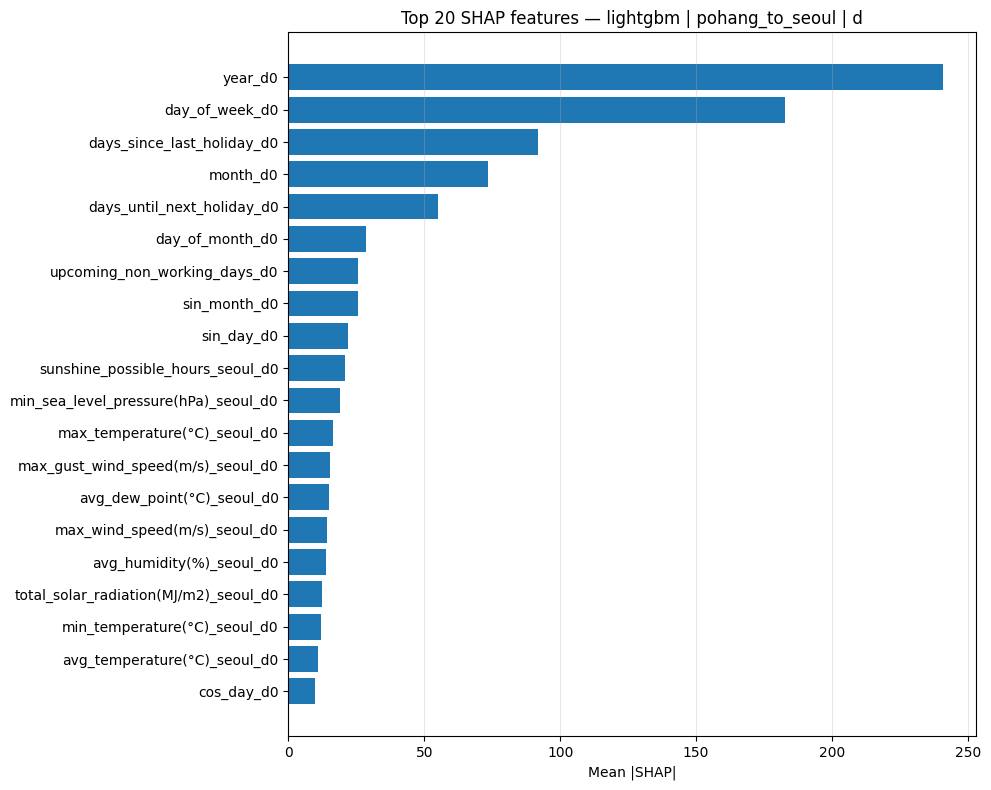

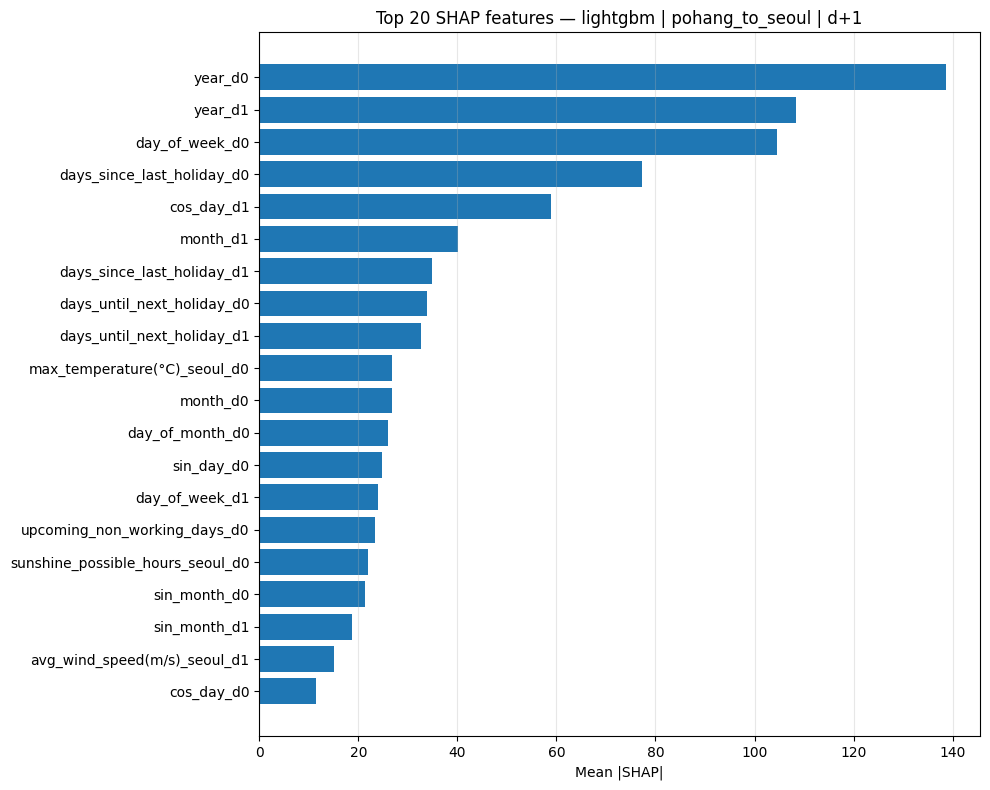

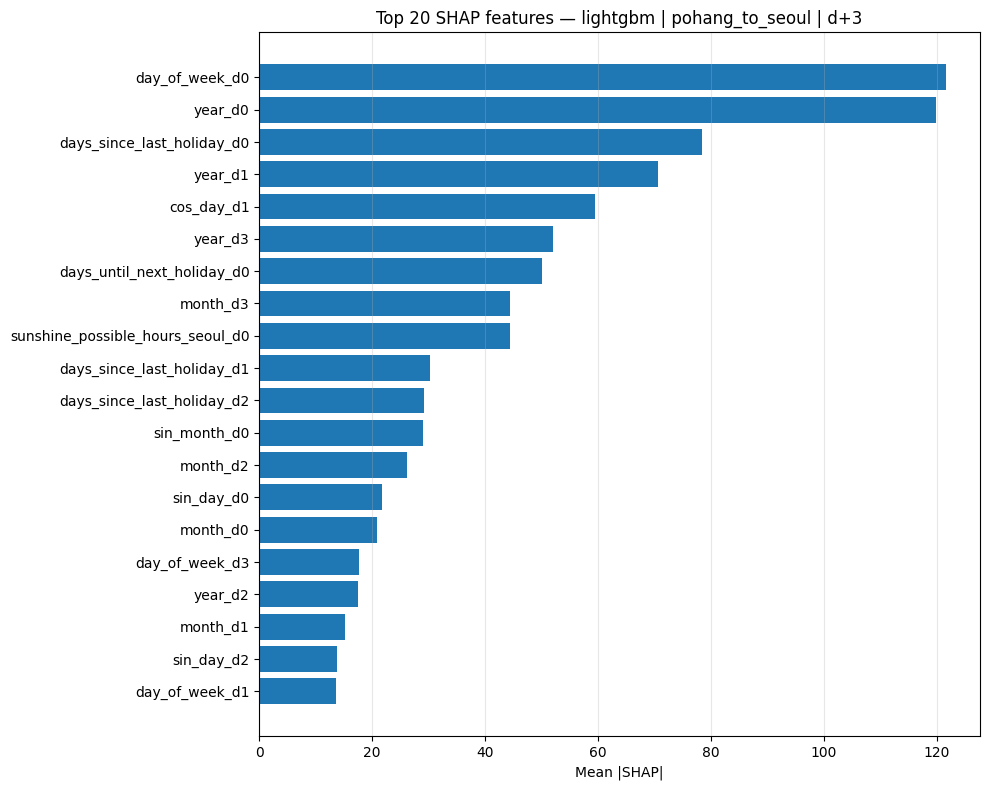

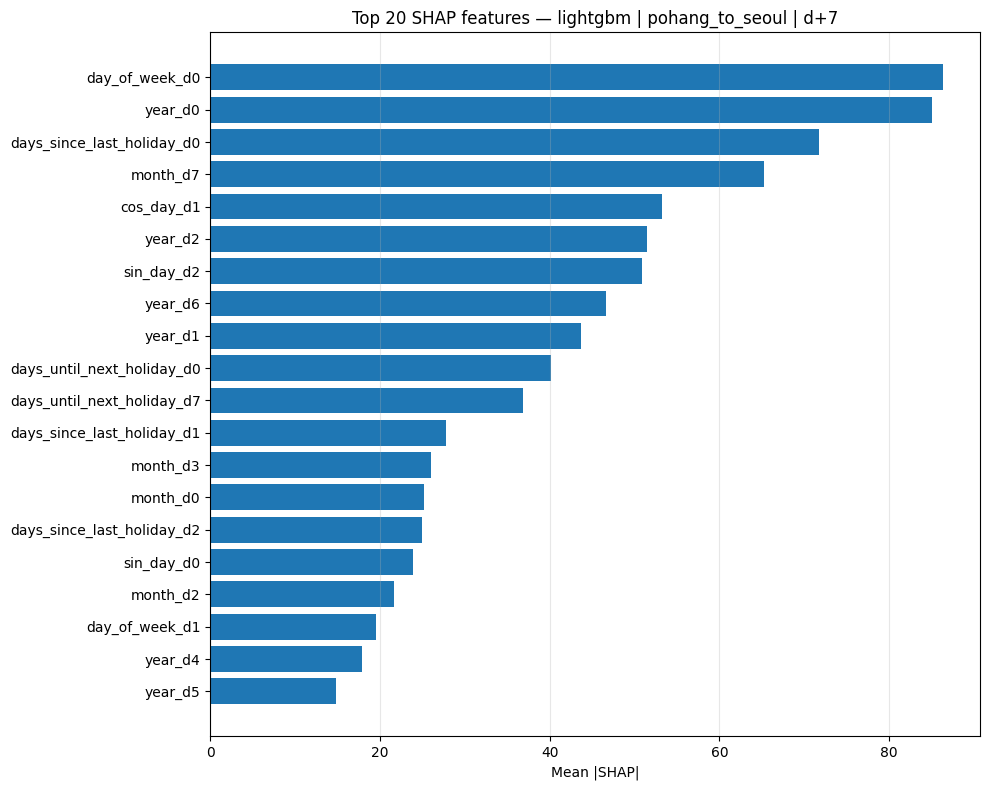

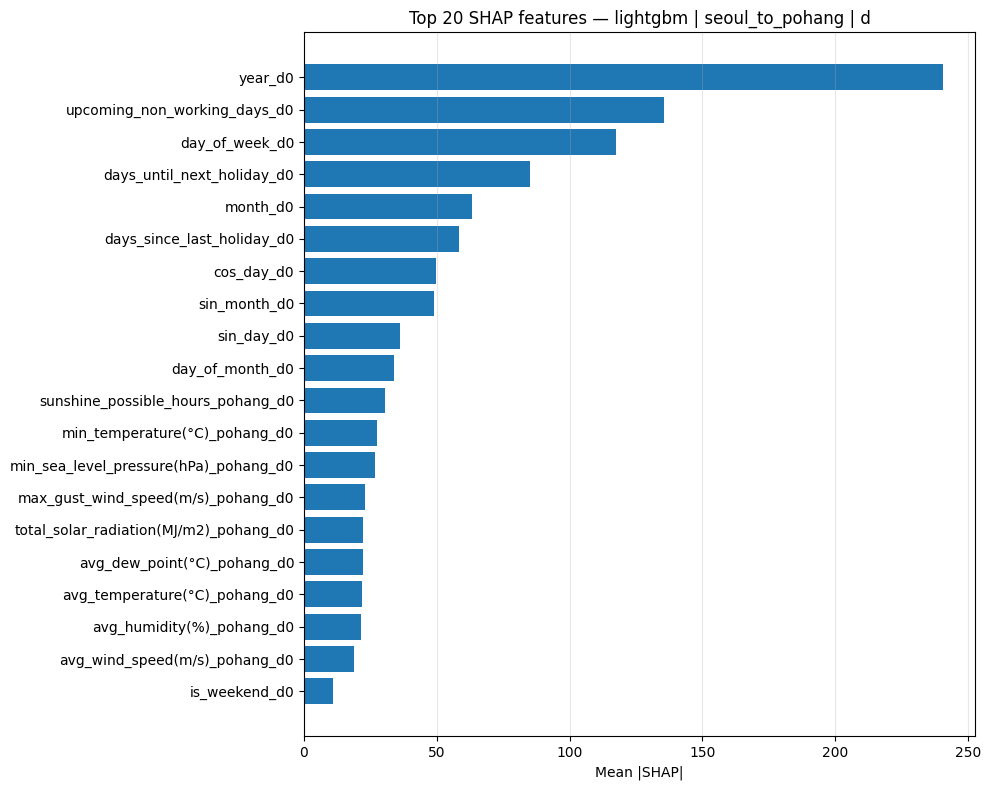

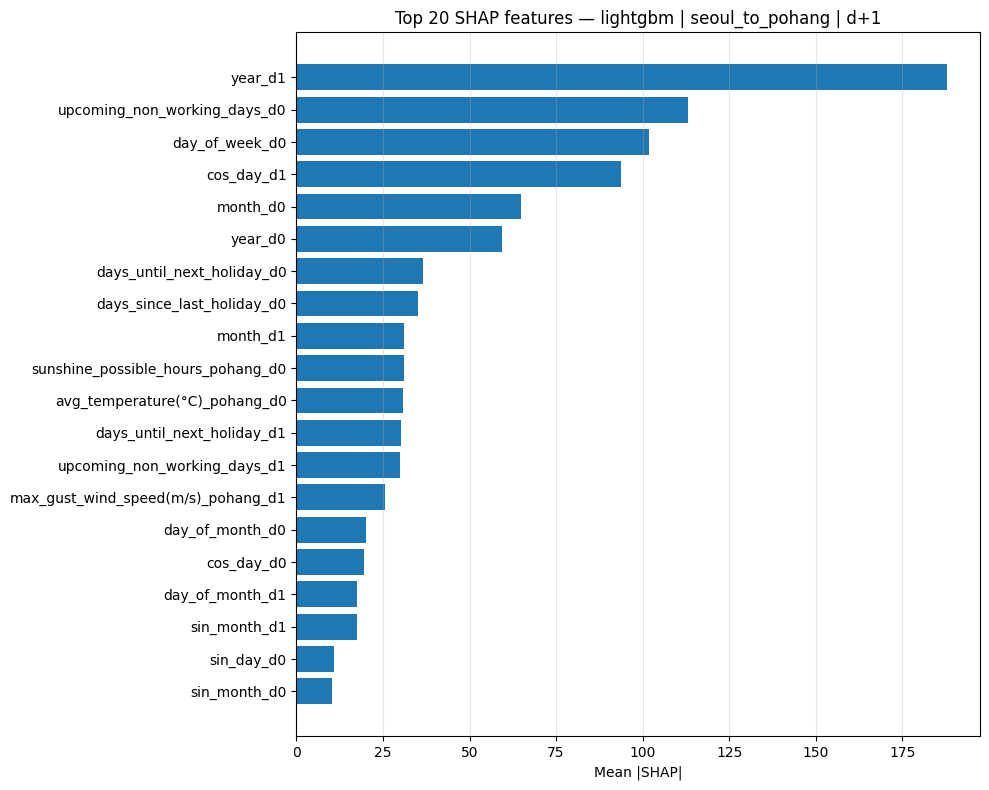

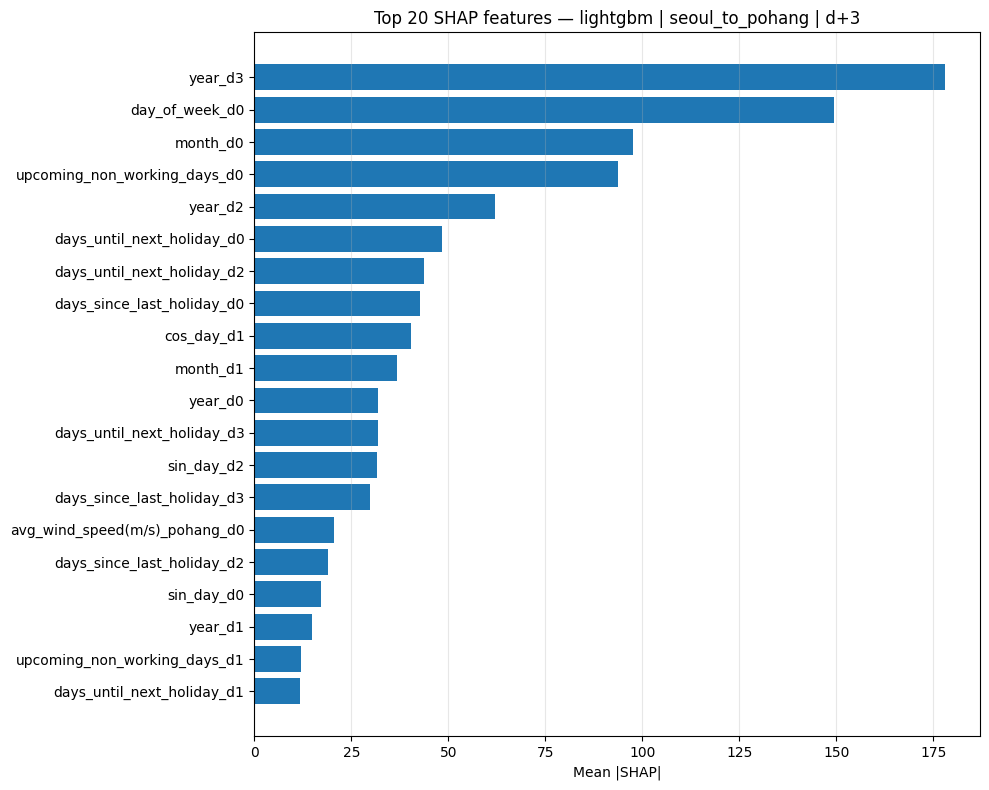

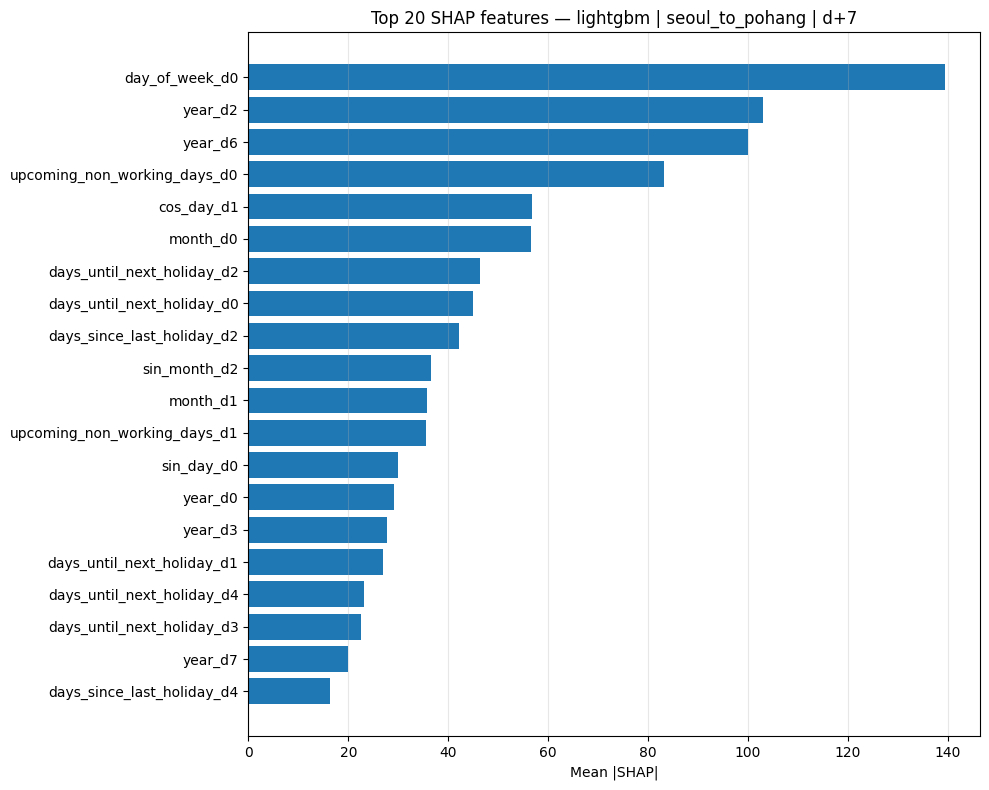

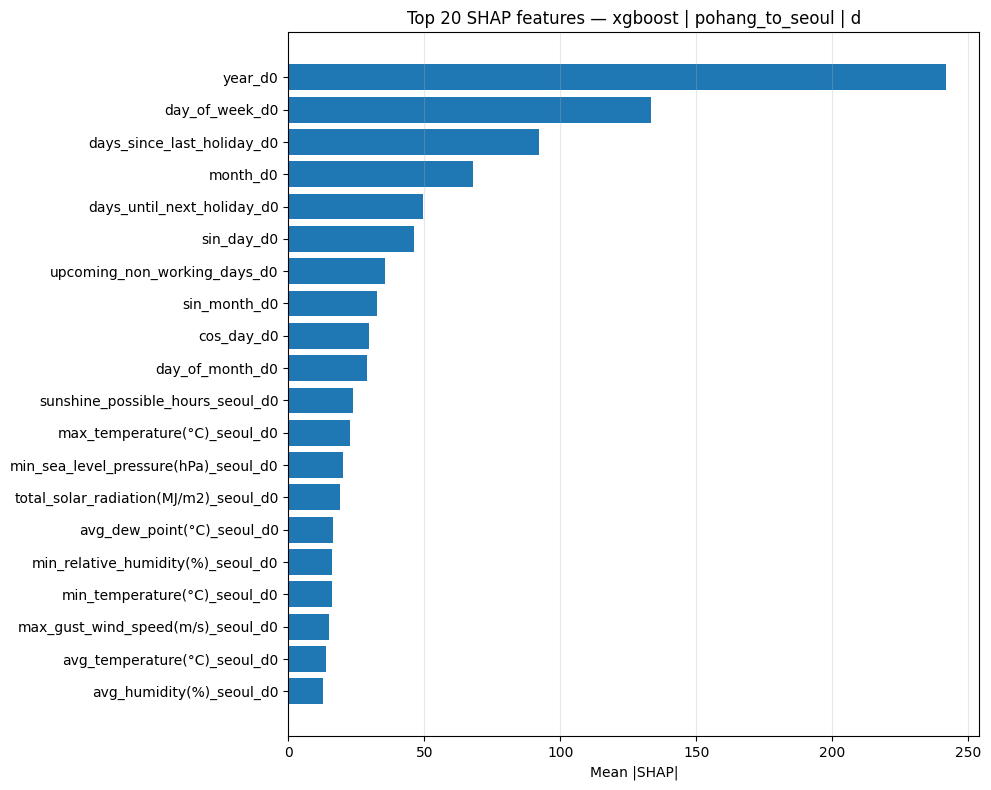

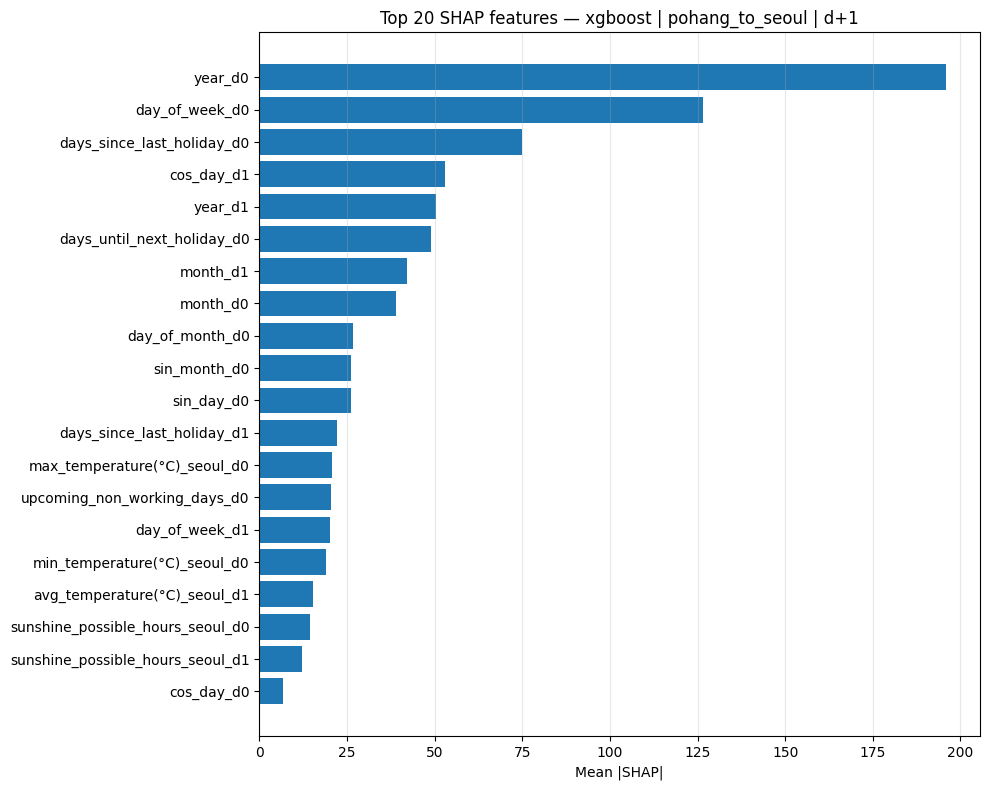

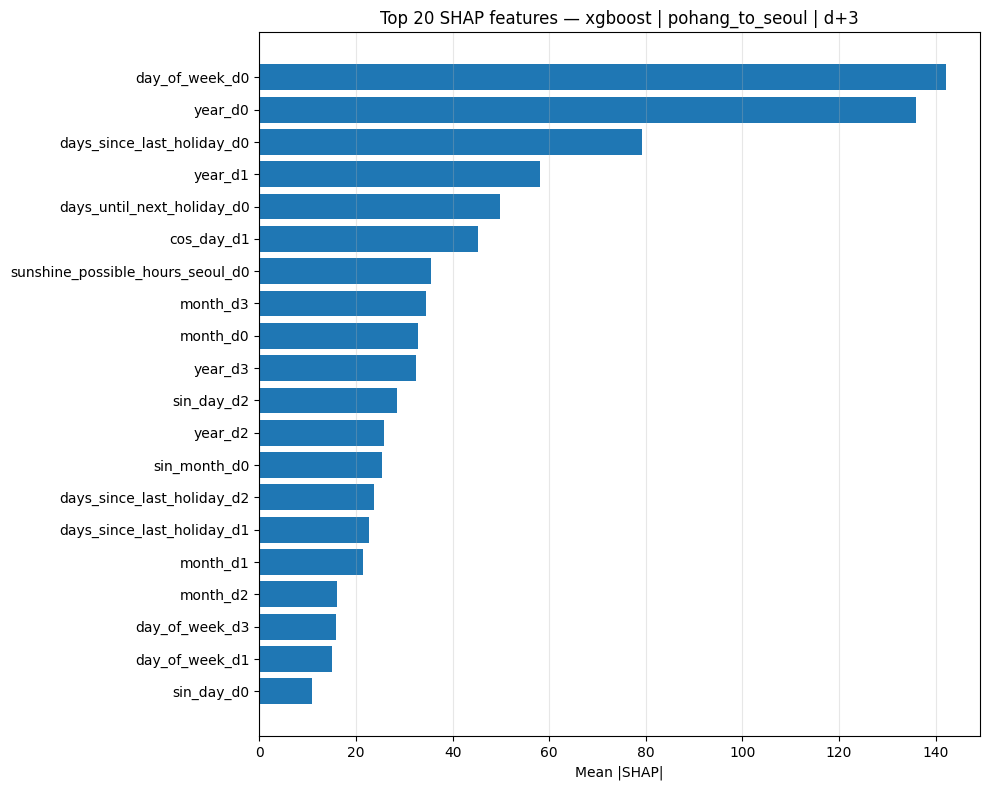

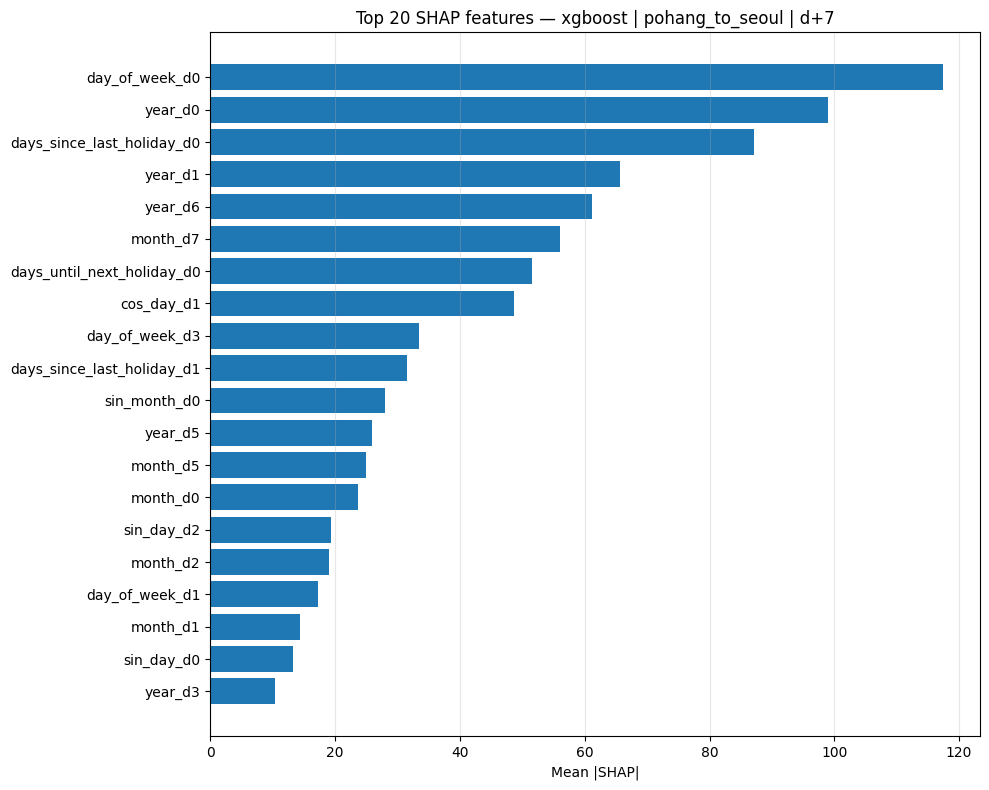

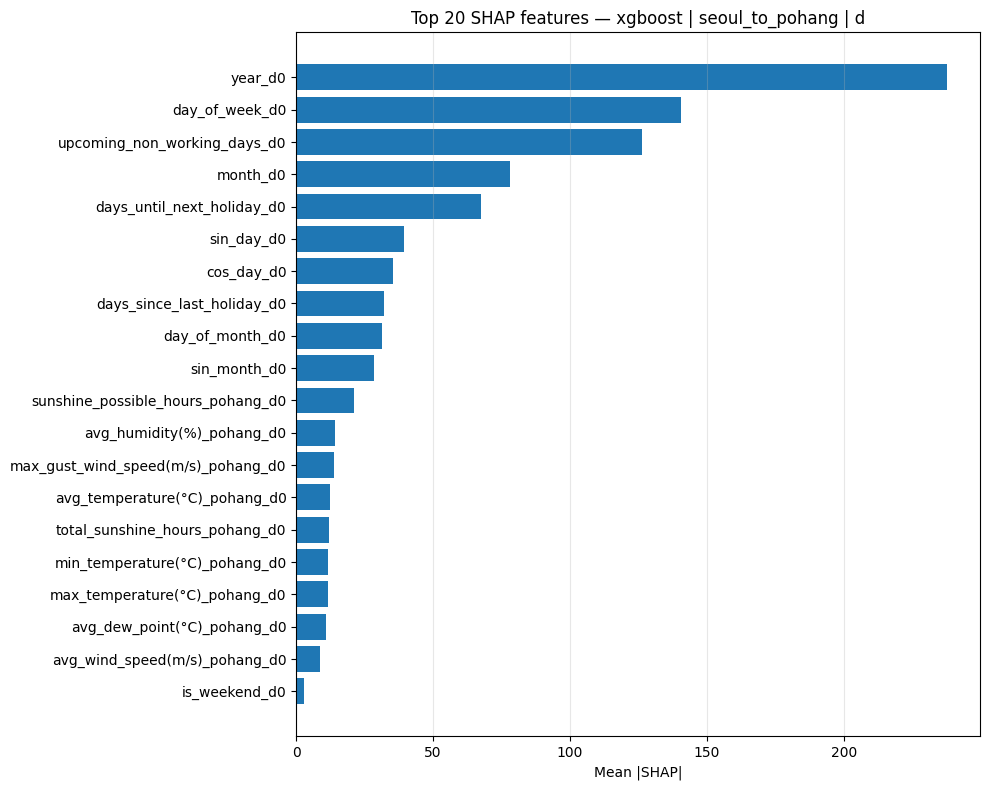

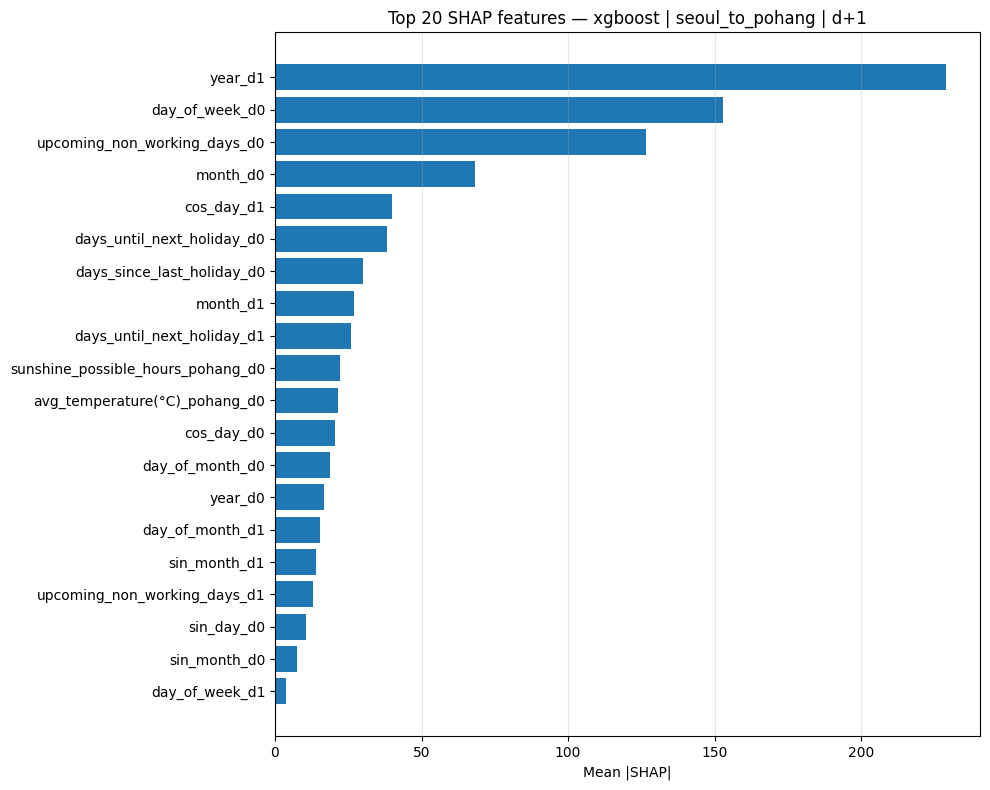

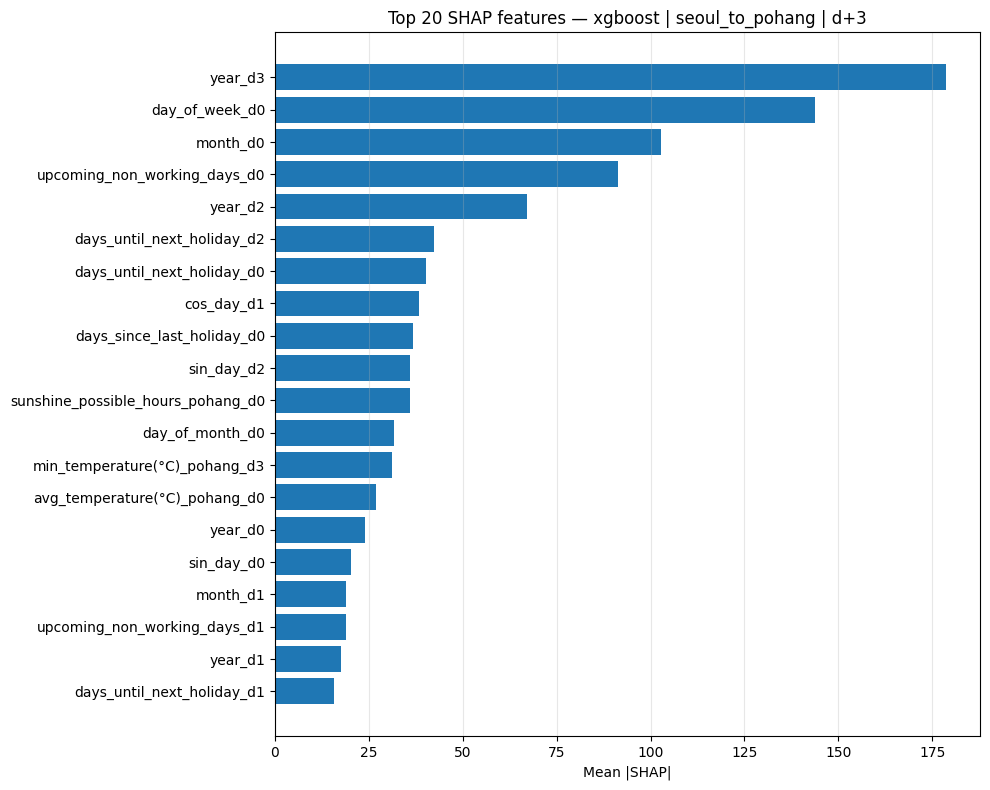

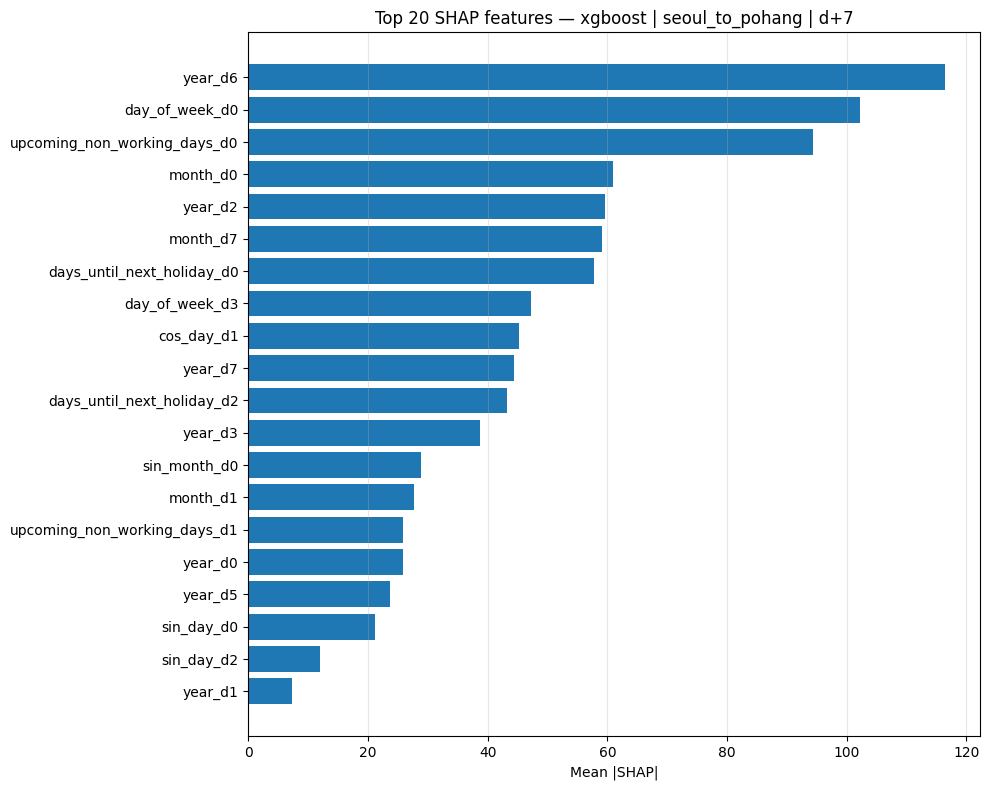

In [7]:

def plot_topk(case_id: str, n: int = TOP_K):
    sub = topk[topk["case_id"] == case_id].copy()
    sub = sub.sort_values("importance", ascending=True).tail(n)

    fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(sub) + 1)))
    ax.barh(sub["feature"], sub["importance"])
    ax.set_title(f"Top {n} SHAP features — {case_id}")
    ax.set_xlabel("Mean |SHAP|")
    ax.set_ylabel("")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    return fig

for case_id in case_order:
    fig = plot_topk(case_id, n=TOP_K)
    plt.show()


## 4) Family-level importance

In [8]:

family_summary = (
    all_shap
    .groupby(["model", "route", "horizon", "horizon_days", "case_id", "family"], as_index=False)
    .agg(
        importance=("importance", "sum"),
        share=("importance_share", "sum"),
        n_features=("feature", "count"),
    )
    .sort_values(["model", "route", "horizon_days", "importance"], ascending=[True, True, True, False])
)

display(family_summary.head(30))


,model,route,horizon,horizon_days,case_id,family,importance,share,n_features
0,lightgbm,pohang_to_seoul,d,0,lightgbm | pohang_to_seoul | d,calendar,755.032241,0.834701,10
4,lightgbm,pohang_to_seoul,d,0,lightgbm | pohang_to_seoul | d,temperature,39.101511,0.043227,3
3,lightgbm,pohang_to_seoul,d,0,lightgbm | pohang_to_seoul | d,sunshine,33.088860,0.036580,2
5,lightgbm,pohang_to_seoul,d,0,lightgbm | pohang_to_seoul | d,wind,29.354033,0.032451,2
1,lightgbm,pohang_to_seoul,d,0,lightgbm | pohang_to_seoul | d,humidity,28.945874,0.032000,2
2,lightgbm,pohang_to_seoul,d,0,lightgbm | pohang_to_seoul | d,pressure,19.031402,0.021040,1
6,lightgbm,pohang_to_seoul,d+1,1,lightgbm | pohang_to_seoul | d+1,calendar,805.831323,0.926598,17
8,lightgbm,pohang_to_seoul,d+1,1,lightgbm | pohang_to_seoul | d+1,temperature,26.832224,0.030853,1
7,lightgbm,pohang_to_seoul,d+1,1,lightgbm | pohang_to_seoul | d+1,sunshine,21.912292,0.025196,1
9,lightgbm,pohang_to_seoul,d+1,1,lightgbm | pohang_to_seoul | d+1,wind,15.090304,0.017352,1


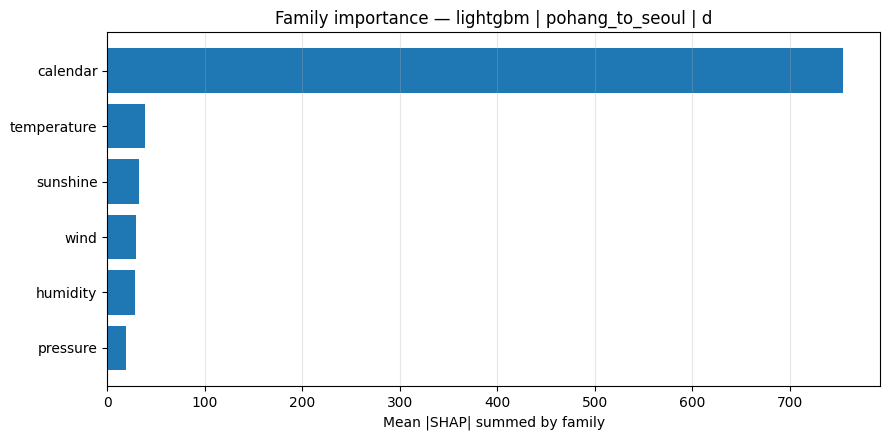

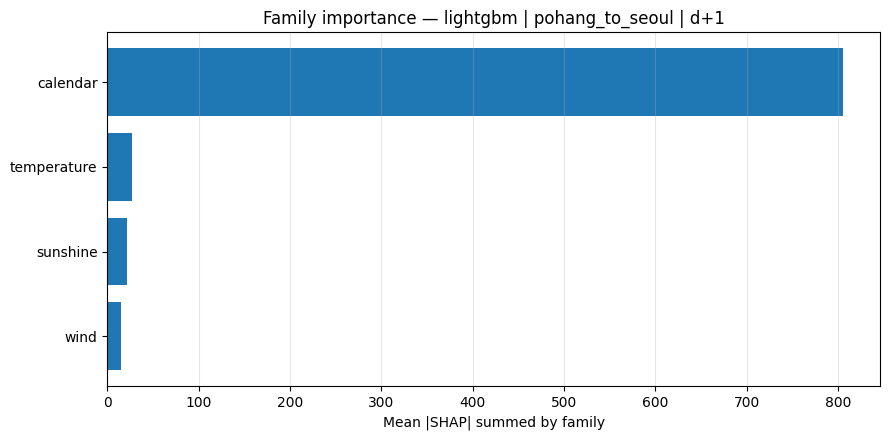

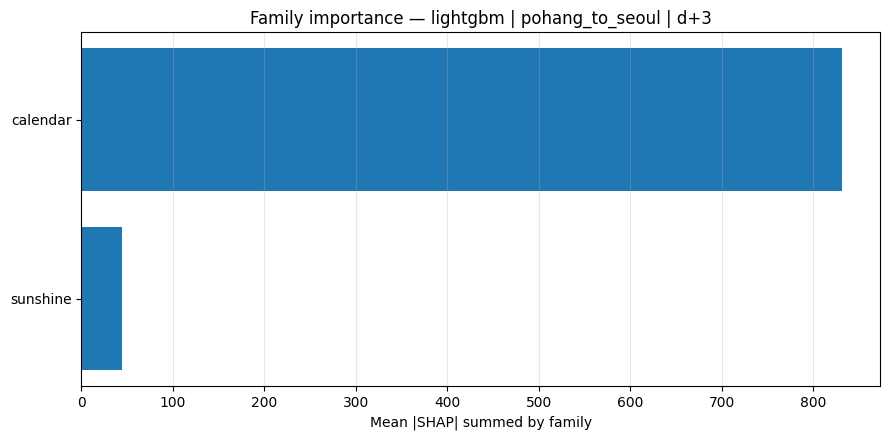

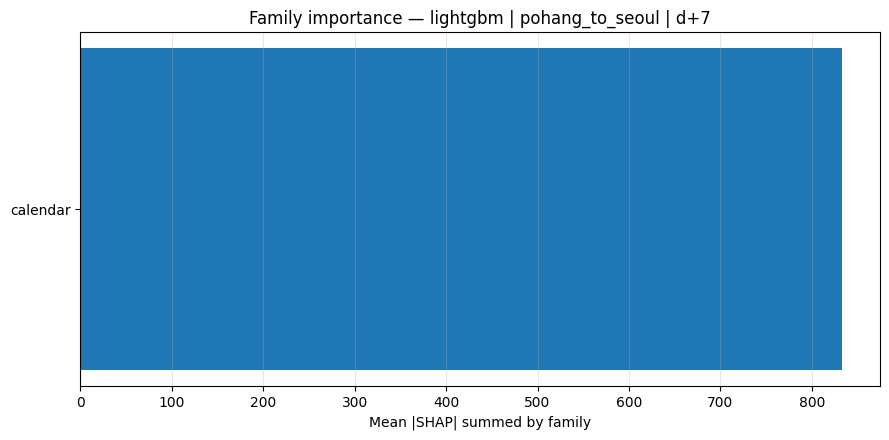

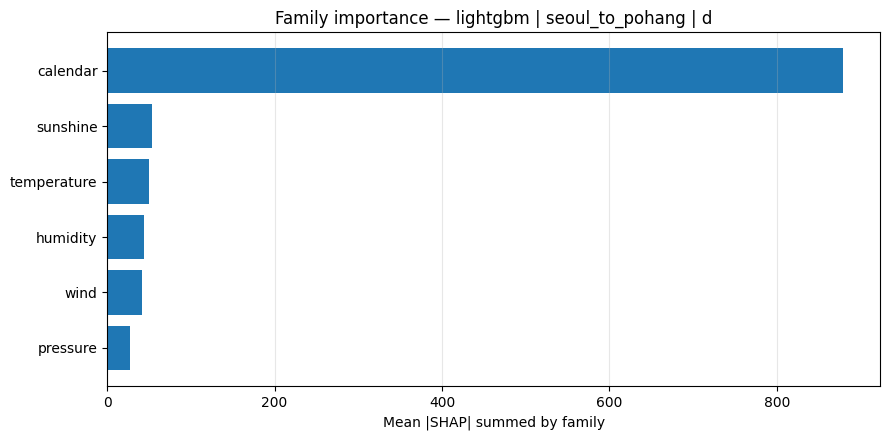

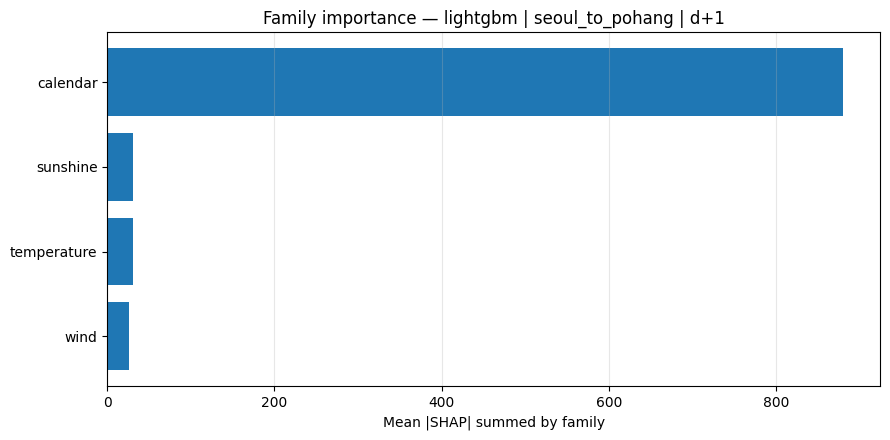

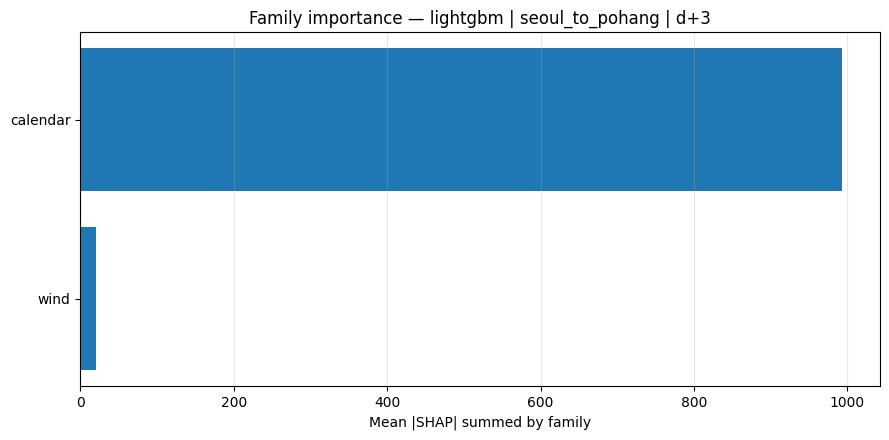

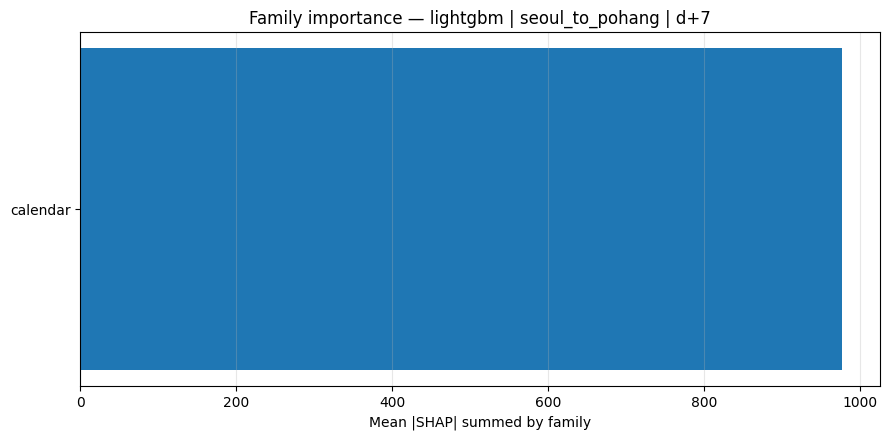

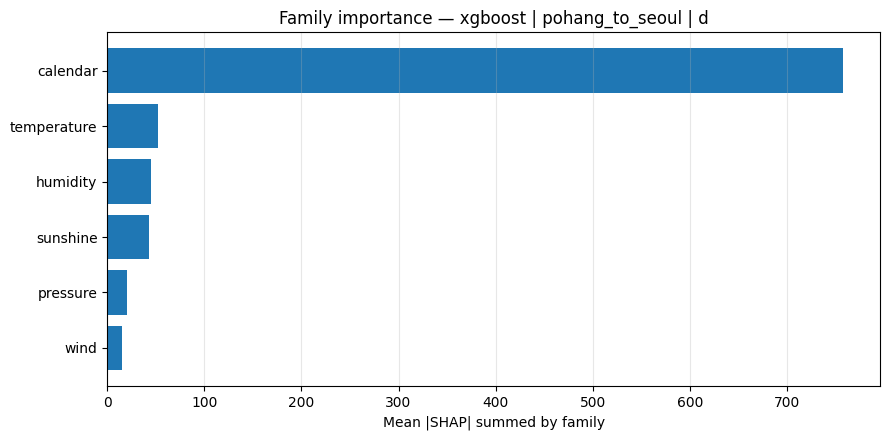

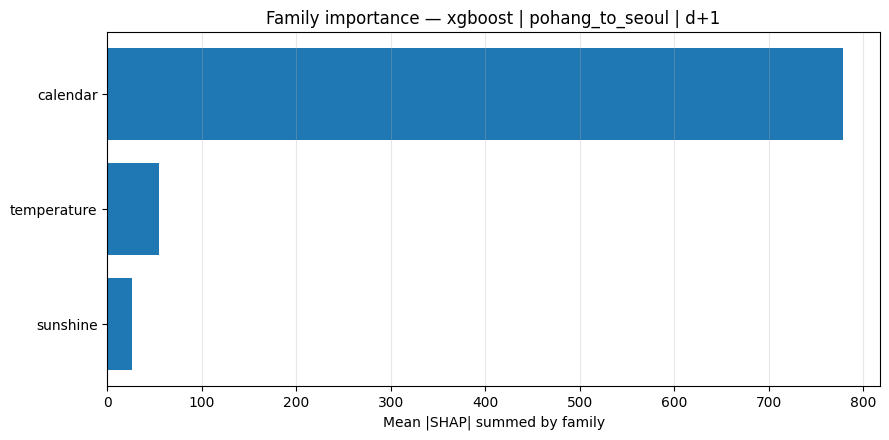

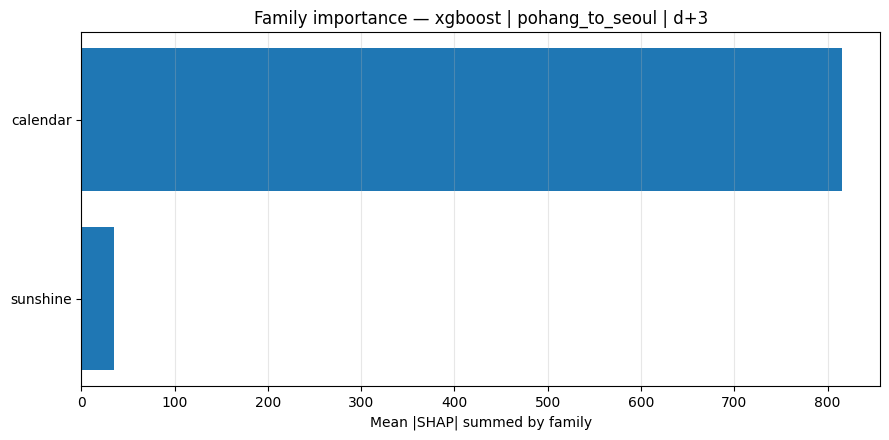

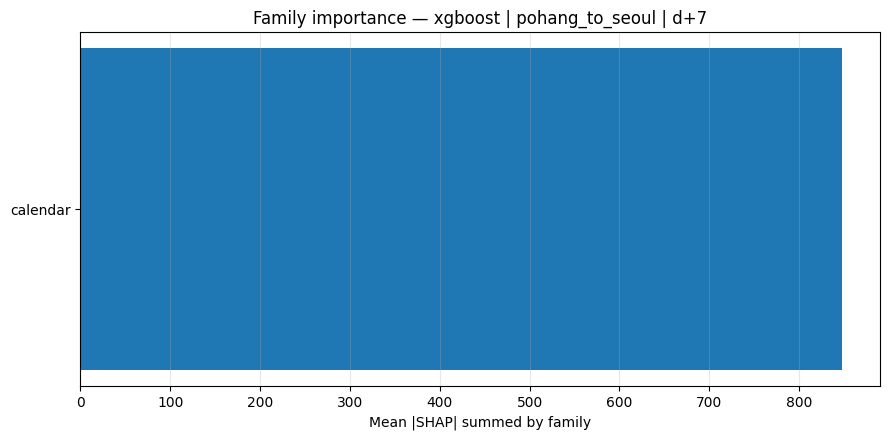

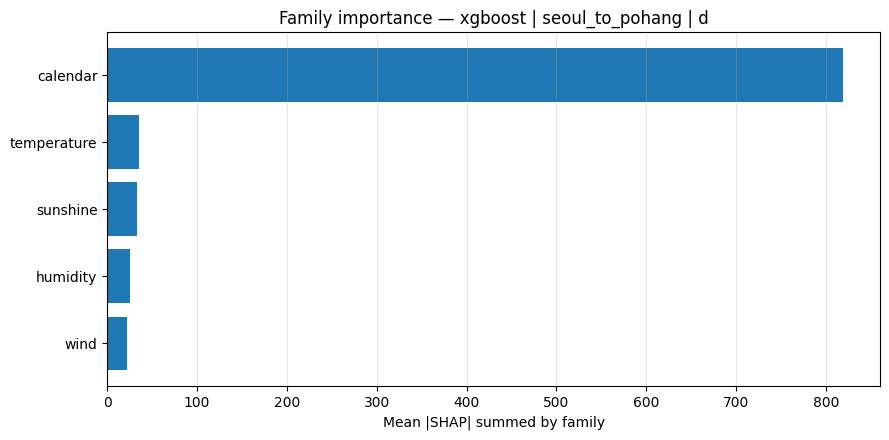

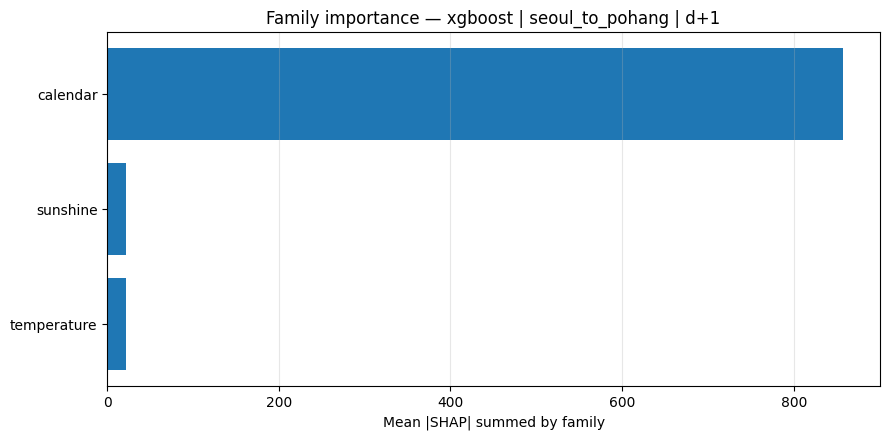

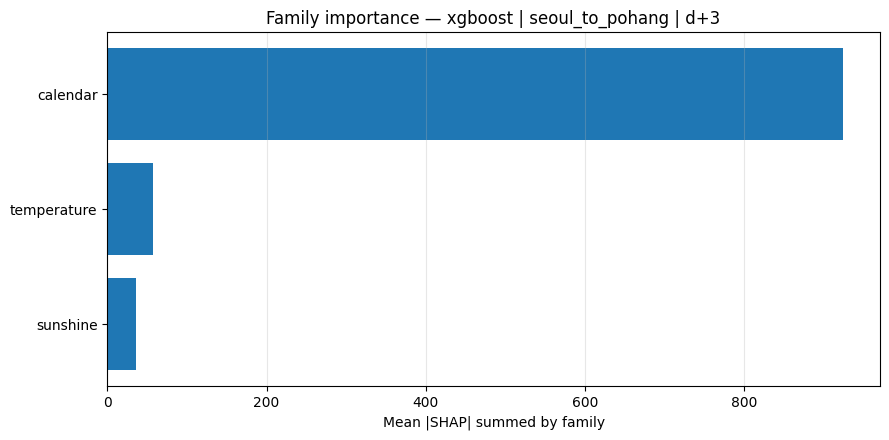

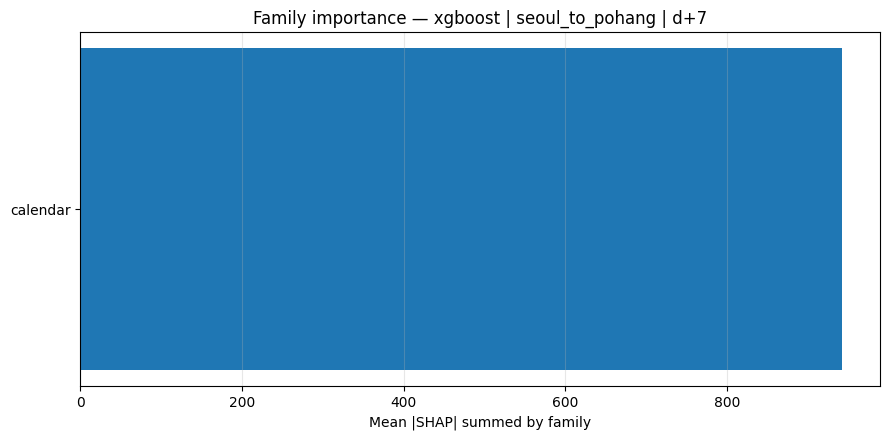

In [9]:

family_order = ["calendar", "temperature", "precipitation", "wind", "sunshine", "humidity", "pressure", "cloud", "snow", "fog", "other"]

def plot_family_importance(case_id: str):
    sub = family_summary[family_summary["case_id"] == case_id].copy()
    if sub.empty:
        return None

    sub["family"] = pd.Categorical(sub["family"], categories=family_order, ordered=True)
    sub = sub.sort_values("importance", ascending=True)

    fig, ax = plt.subplots(figsize=(9, max(4.5, 0.35 * len(sub) + 1)))
    ax.barh(sub["family"].astype(str), sub["importance"])
    ax.set_title(f"Family importance — {case_id}")
    ax.set_xlabel("Mean |SHAP| summed by family")
    ax.set_ylabel("")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    return fig

for case_id in case_order:
    fig = plot_family_importance(case_id)
    if fig is not None:
        plt.show()



## 5) Family share across horizons

This section shows how the relative contribution of families changes with the forecast horizon.


In [10]:

family_share = (
    family_summary
    .groupby(["model", "route", "horizon", "horizon_days", "case_id", "family"], as_index=False)["importance"]
    .sum()
)

family_share["family_share"] = family_share.groupby("case_id")["importance"].transform(lambda s: s / s.sum())

family_share_pivot = (
    family_share
    .pivot_table(index=["model", "route", "horizon", "horizon_days", "case_id"], columns="family", values="family_share", fill_value=0)
    .reset_index()
)

display(family_share_pivot.head(20))


family,model,route,horizon,horizon_days,case_id,calendar,humidity,pressure,sunshine,temperature,wind
0,lightgbm,pohang_to_seoul,d,0,lightgbm | pohang_to_seoul | d,0.834701,0.032000,0.021040,0.036580,0.043227,0.032451
1,lightgbm,pohang_to_seoul,d+1,1,lightgbm | pohang_to_seoul | d+1,0.926598,0.000000,0.000000,0.025196,0.030853,0.017352
2,lightgbm,pohang_to_seoul,d+3,3,lightgbm | pohang_to_seoul | d+3,0.949257,0.000000,0.000000,0.050743,0.000000,0.000000
3,lightgbm,pohang_to_seoul,d+7,7,lightgbm | pohang_to_seoul | d+7,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,lightgbm,seoul_to_pohang,d,0,lightgbm | seoul_to_pohang | d,0.803786,0.039999,0.024392,0.048380,0.045190,0.038253
5,lightgbm,seoul_to_pohang,d+1,1,lightgbm | seoul_to_pohang | d+1,0.909430,0.000000,0.000000,0.032193,0.031836,0.026540
6,lightgbm,seoul_to_pohang,d+3,3,lightgbm | seoul_to_pohang | d+3,0.979841,0.000000,0.000000,0.000000,0.000000,0.020159
7,lightgbm,seoul_to_pohang,d+7,7,lightgbm | seoul_to_pohang | d+7,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,xgboost,pohang_to_seoul,d,0,xgboost | pohang_to_seoul | d,0.811788,0.048404,0.021367,0.045980,0.056299,0.016162
9,xgboost,pohang_to_seoul,d+1,1,xgboost | pohang_to_seoul | d+1,0.905625,0.000000,0.000000,0.030732,0.063643,0.000000


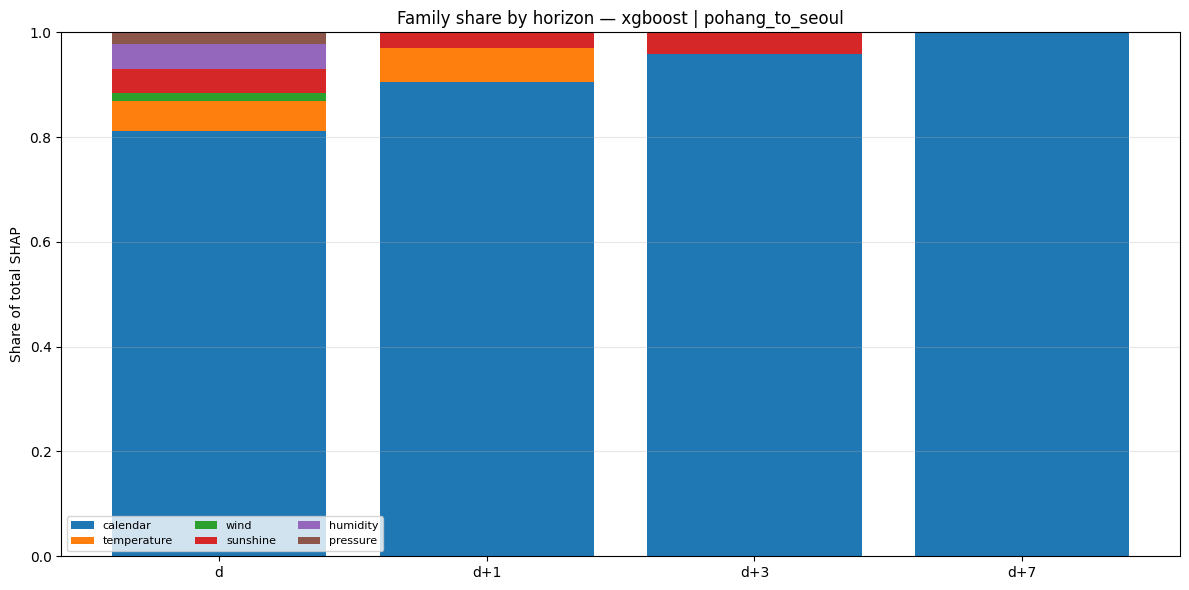

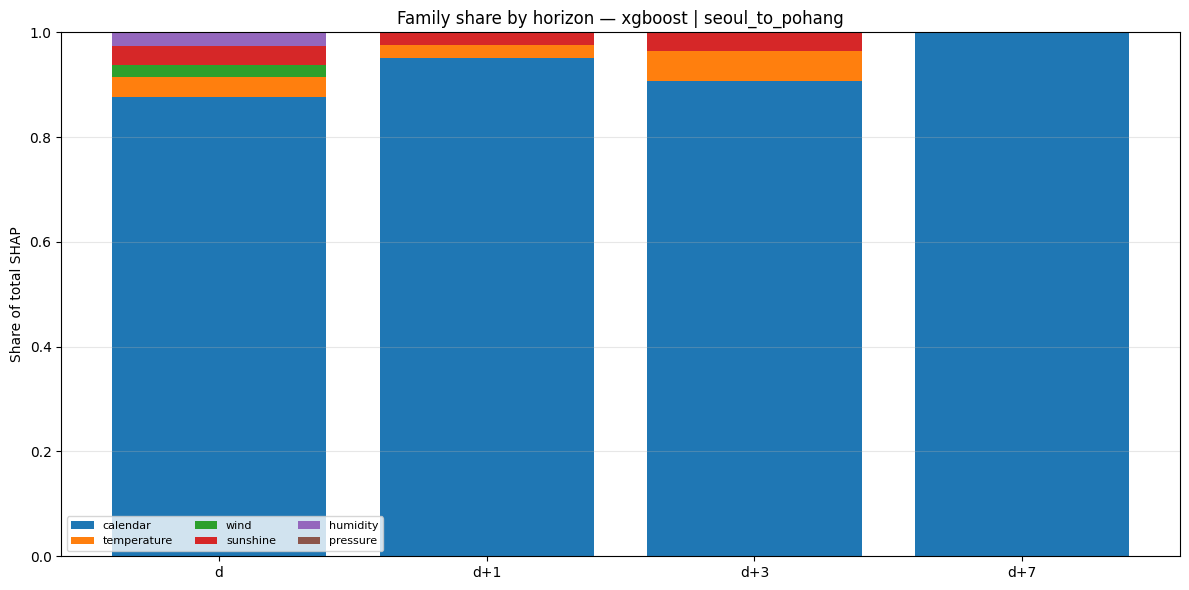

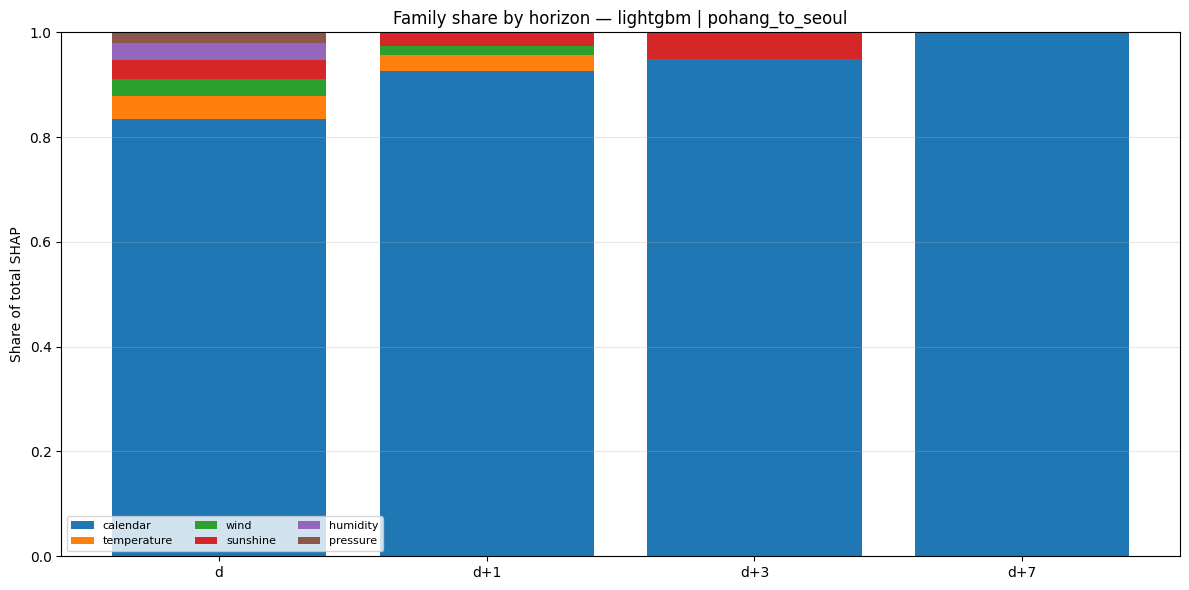

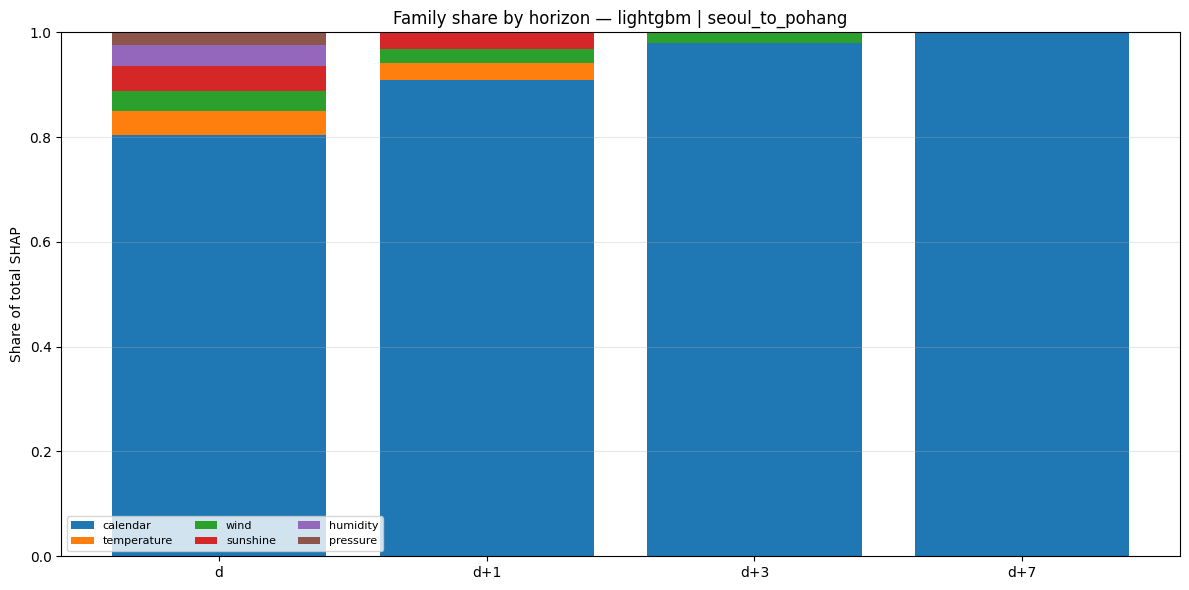

In [11]:

def plot_family_share_by_route(route: str, model: str):
    sub = family_share_pivot[(family_share_pivot["route"] == route) & (family_share_pivot["model"] == model)].copy()
    if sub.empty:
        return None

    sub = sub.sort_values("horizon_days")
    x = np.arange(len(sub))
    bottom = np.zeros(len(sub))

    fig, ax = plt.subplots(figsize=(12, 6))
    for fam in family_order:
        if fam not in sub.columns:
            continue
        values = sub[fam].values
        ax.bar(x, values, bottom=bottom, label=fam)
        bottom += values

    ax.set_xticks(x)
    ax.set_xticklabels(sub["horizon"], rotation=0)
    ax.set_ylabel("Share of total SHAP")
    ax.set_title(f"Family share by horizon — {model} | {route}")
    ax.legend(ncol=3, fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    return fig

for model in ["xgboost", "lightgbm"]:
    for route in sorted(all_shap["route"].unique()):
        fig = plot_family_share_by_route(route, model)
        if fig is not None:
            plt.show()


## 6) Concentration inside correlated families

In [12]:

# If the importance is spread across many sibling features, concentration is low.
# If one feature dominates the family, concentration is high.
family_concentration = (
    all_shap
    .groupby(["model", "route", "horizon", "horizon_days", "case_id", "family"], as_index=False)
    .agg(
        family_total=("importance", "sum"),
        family_max=("importance", "max"),
        family_n=("feature", "count"),
    )
)

family_concentration["max_share_in_family"] = family_concentration["family_max"] / family_concentration["family_total"]
display(family_concentration.sort_values(["model", "route", "horizon_days", "family"]).head(30))


,model,route,horizon,horizon_days,case_id,family,family_total,family_max,family_n,max_share_in_family
0,lightgbm,pohang_to_seoul,d,0,lightgbm | pohang_to_seoul | d,calendar,755.032241,240.984407,10,0.319171
1,lightgbm,pohang_to_seoul,d,0,lightgbm | pohang_to_seoul | d,humidity,28.945874,15.092176,2,0.521393
2,lightgbm,pohang_to_seoul,d,0,lightgbm | pohang_to_seoul | d,pressure,19.031402,19.031402,1,1.000000
3,lightgbm,pohang_to_seoul,d,0,lightgbm | pohang_to_seoul | d,sunshine,33.088860,20.800833,2,0.628636
4,lightgbm,pohang_to_seoul,d,0,lightgbm | pohang_to_seoul | d,temperature,39.101511,16.254523,3,0.415701
5,lightgbm,pohang_to_seoul,d,0,lightgbm | pohang_to_seoul | d,wind,29.354033,15.147994,2,0.516045
6,lightgbm,pohang_to_seoul,d+1,1,lightgbm | pohang_to_seoul | d+1,calendar,805.831323,138.606052,17,0.172004
7,lightgbm,pohang_to_seoul,d+1,1,lightgbm | pohang_to_seoul | d+1,sunshine,21.912292,21.912292,1,1.000000
8,lightgbm,pohang_to_seoul,d+1,1,lightgbm | pohang_to_seoul | d+1,temperature,26.832224,26.832224,1,1.000000
9,lightgbm,pohang_to_seoul,d+1,1,lightgbm | pohang_to_seoul | d+1,wind,15.090304,15.090304,1,1.000000


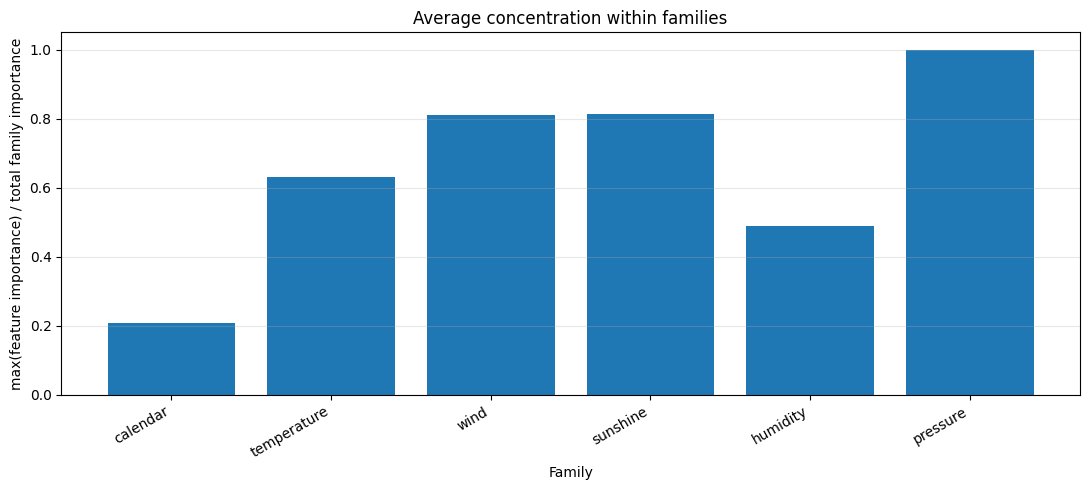

In [13]:

def plot_family_concentration():
    avg = (
        family_concentration
        .groupby("family", as_index=False)["max_share_in_family"]
        .mean()
        .sort_values("max_share_in_family", ascending=False)
    )
    avg["family"] = pd.Categorical(avg["family"], categories=family_order, ordered=True)
    avg = avg.sort_values("family")

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(avg["family"].astype(str), avg["max_share_in_family"])
    ax.set_title("Average concentration within families")
    ax.set_ylabel("max(feature importance) / total family importance")
    ax.set_xlabel("Family")
    ax.grid(True, axis="y", alpha=0.3)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    return fig

fig = plot_family_concentration()
plt.show()


In [18]:

def family_detail(family_name: str, route: str | None = None, horizon: str | None = None, model: str | None = None, top_n: int = 20):
    sub = all_shap[all_shap["family"] == family_name].copy()
    if route is not None:
        sub = sub[sub["route"] == route]
    if horizon is not None:
        sub = sub[sub["horizon"] == horizon]
    if model is not None:
        sub = sub[sub["model"] == model]

    detail = (
        sub.groupby(["base_feature", "feature"], as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
        .head(top_n)
    )
    return detail

for fam in ["calendar", "temperature", "precipitation", "wind"]:
    print(f"=== {fam.upper()} ===")
    display(family_detail(fam, route="pohang_to_seoul", horizon="d+3", model="xgboost", top_n=20))


=== CALENDAR ===


,base_feature,feature,importance
1,day_of_week,day_of_week_d0,142.074070
15,year,year_d0,135.840880
4,days_since_last_holiday,days_since_last_holiday_d0,79.164505
16,year,year_d1,58.088560
7,days_until_next_holiday,days_until_next_holiday_d0,49.740560
0,cos_day,cos_day_d1,45.162770
11,month,month_d3,34.551740
8,month,month_d0,32.749584
18,year,year_d3,32.358475
13,sin_day,sin_day_d2,28.484467


=== TEMPERATURE ===


,base_feature,feature,importance


=== PRECIPITATION ===


,base_feature,feature,importance


=== WIND ===


,base_feature,feature,importance


## 7) Importance by day offset

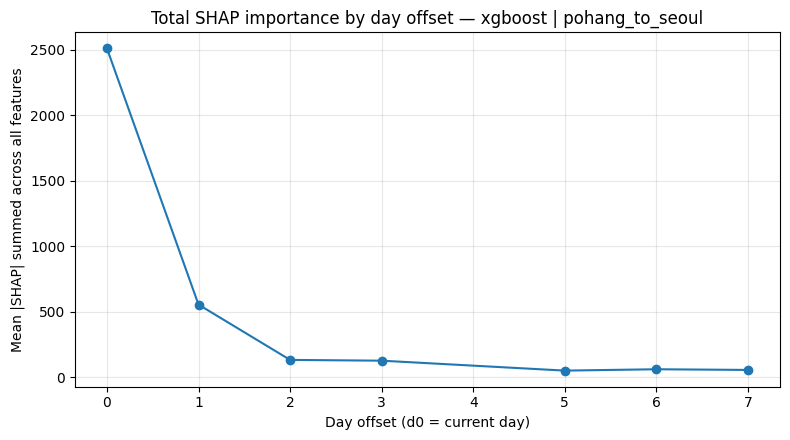

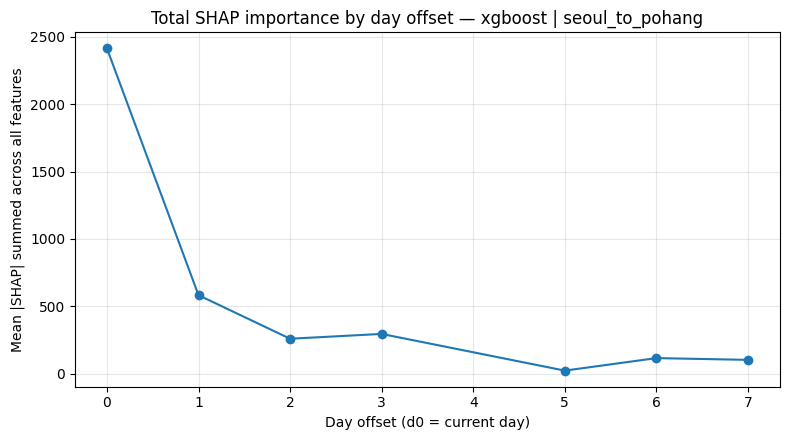

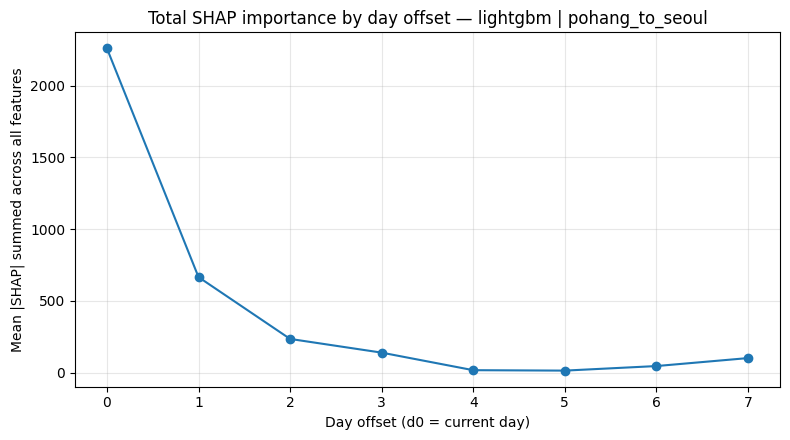

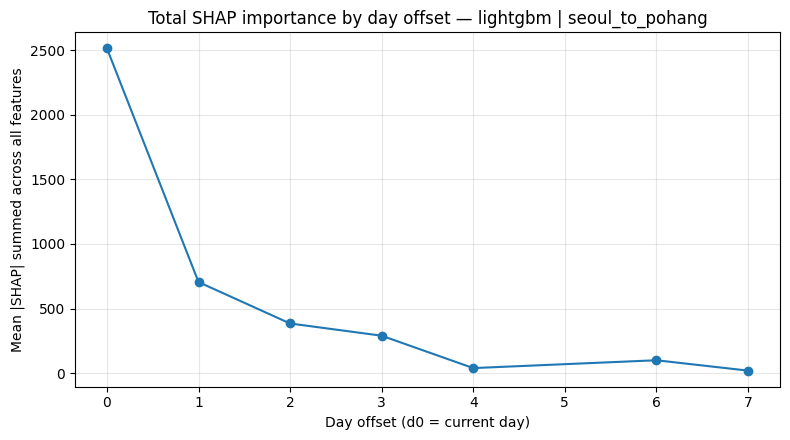

In [19]:

def plot_day_offset_importance(route: str, model: str):
    sub = all_shap[(all_shap["route"] == route) & (all_shap["model"] == model)].copy()
    agg = (
        sub.groupby("day_offset", as_index=False)["importance"]
        .sum()
        .sort_values("day_offset")
    )

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(agg["day_offset"], agg["importance"], marker="o")
    ax.set_title(f"Total SHAP importance by day offset — {model} | {route}")
    ax.set_xlabel("Day offset (d0 = current day)")
    ax.set_ylabel("Mean |SHAP| summed across all features")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

for model in ["xgboost", "lightgbm"]:
    for route in sorted(all_shap["route"].unique()):
        fig = plot_day_offset_importance(route, model)
        plt.show()


## 8) Top positive drivers

In [20]:
for case_id in case_order:

    sub = (
        all_shap[
            (all_shap["case_id"] == case_id)
            &
            (all_shap["feature_shap_corr"] > 0)
        ]
        .sort_values(
            "importance",
            ascending=False
        )
        .head(20)
    )

    print("=" * 100)
    print(case_id)
    print("TOP POSITIVE DRIVERS")

    display(
        sub[
            [
                "feature",
                "importance",
                "feature_shap_corr"
            ]
        ]
    )

lightgbm | pohang_to_seoul | d
TOP POSITIVE DRIVERS


,feature,importance,feature_shap_corr
300,year_d0,240.984407,0.872353
301,day_of_week_d0,182.640456,0.803631
303,month_d0,73.320397,0.767858
305,day_of_month_d0,28.472061,0.702885
306,upcoming_non_working_days_d0,25.535671,0.517318
313,avg_dew_point(°C)_seoul_d0,15.092176,0.426200
314,max_wind_speed(m/s)_seoul_d0,14.206039,0.489689
315,avg_humidity(%)_seoul_d0,13.853698,0.173114
316,total_solar_radiation(MJ/m2)_seoul_d0,12.288027,0.267373
317,min_temperature(°C)_seoul_d0,12.016194,0.153335


lightgbm | pohang_to_seoul | d+1
TOP POSITIVE DRIVERS


,feature,importance,feature_shap_corr
220,year_d0,138.606052,0.874119
221,year_d1,108.468963,0.854860
222,day_of_week_d0,104.474764,0.810476
224,cos_day_d1,58.858767,0.852758
225,month_d1,40.105579,0.755139
228,days_until_next_holiday_d1,32.739523,0.319844
229,max_temperature(°C)_seoul_d0,26.832224,0.288348
230,month_d0,26.690702,0.746619
231,day_of_month_d0,26.046692,0.574790
234,upcoming_non_working_days_d0,23.306597,0.766110


lightgbm | pohang_to_seoul | d+3
TOP POSITIVE DRIVERS


...

,feature,importance,feature_shap_corr
120,year_d1,229.051280,0.864436
121,day_of_week_d0,152.742100,0.846482
122,upcoming_non_working_days_d0,126.702330,0.773004
123,month_d0,68.189560,0.840132
124,cos_day_d1,39.826260,0.732750
126,days_since_last_holiday_d0,29.949429,0.396057
127,month_d1,26.997797,0.713992
130,avg_temperature(°C)_pohang_d0,21.425850,0.432567
131,cos_day_d0,20.505896,0.842600
132,day_of_month_d0,18.834341,0.792438


xgboost | seoul_to_pohang | d+3
TOP POSITIVE DRIVERS


,feature,importance,feature_shap_corr
20,year_d3,178.790440,0.882779
21,day_of_week_d0,143.779820,0.851042
22,month_d0,102.749275,0.902227
23,upcoming_non_working_days_d0,91.221664,0.733109
24,year_d2,67.007050,0.756841
27,cos_day_d1,38.232918,0.823442
28,days_since_last_holiday_d0,36.764940,0.226964
29,sin_day_d2,35.910576,0.797518
31,day_of_month_d0,31.739725,0.720712
32,min_temperature(°C)_pohang_d3,31.085905,0.388393


xgboost | seoul_to_pohang | d+7
TOP POSITIVE DRIVERS


,feature,importance,feature_shap_corr
40,year_d6,116.469020,0.932617
41,day_of_week_d0,102.188970,0.819579
42,upcoming_non_working_days_d0,94.364160,0.741935
43,month_d0,61.013510,0.766043
44,year_d2,59.685932,0.630831
45,month_d7,59.086746,0.717352
48,cos_day_d1,45.179024,0.936127
49,year_d7,44.408768,0.929979
51,year_d3,38.743710,0.730180
53,month_d1,27.722984,0.065841


## 9) Top positive drivers

In [21]:
for case_id in case_order:

    sub = (
        all_shap[
            (all_shap["case_id"] == case_id)
            &
            (all_shap["feature_shap_corr"] < 0)
        ]
        .sort_values(
            "importance",
            ascending=False
        )
        .head(20)
    )

    print("=" * 100)
    print(case_id)
    print("TOP NEGATIVE DRIVERS")

    display(
        sub[
            [
                "feature",
                "importance",
                "feature_shap_corr"
            ]
        ]
    )

lightgbm | pohang_to_seoul | d
TOP NEGATIVE DRIVERS


,feature,importance,feature_shap_corr
302,days_since_last_holiday_d0,91.658646,-0.222652
304,days_until_next_holiday_d0,55.186926,-0.233926
307,sin_month_d0,25.444385,-0.482252
308,sin_day_d0,22.065322,-0.722885
309,sunshine_possible_hours_seoul_d0,20.800833,-0.361047
310,min_sea_level_pressure(hPa)_seoul_d0,19.031402,-0.346625
311,max_temperature(°C)_seoul_d0,16.254523,-0.282581
312,max_gust_wind_speed(m/s)_seoul_d0,15.147994,-0.598498


lightgbm | pohang_to_seoul | d+1
TOP NEGATIVE DRIVERS


,feature,importance,feature_shap_corr
223,days_since_last_holiday_d0,77.345688,-0.254023
226,days_since_last_holiday_d1,34.950507,-0.087654
227,days_until_next_holiday_d0,33.820492,-0.330601
232,sin_day_d0,24.869814,-0.811748
233,day_of_week_d1,23.993415,-0.603235
235,sunshine_possible_hours_seoul_d0,21.912292,-0.129118
236,sin_month_d0,21.389067,-0.562529
237,sin_month_d1,18.784416,-0.781507
238,avg_wind_speed(m/s)_seoul_d1,15.090304,-0.066893


lightgbm | pohang_to_seoul | d+3
TOP NEGATIVE DRIVERS


...

,feature,importance,feature_shap_corr
125,days_until_next_holiday_d0,38.093070,-0.516586
128,days_until_next_holiday_d1,25.939880,-0.064526
129,sunshine_possible_hours_pohang_d0,22.351835,-0.078682
135,sin_month_d1,14.090650,-0.250364
137,sin_day_d0,10.620182,-0.701364
138,sin_month_d0,7.513530,-0.399059


xgboost | seoul_to_pohang | d+3
TOP NEGATIVE DRIVERS


,feature,importance,feature_shap_corr
25,days_until_next_holiday_d2,42.332203,-0.116195
26,days_until_next_holiday_d0,40.215824,-0.426525
30,sunshine_possible_hours_pohang_d0,35.869370,-0.337809
34,year_d0,24.020617,-0.310236
35,sin_day_d0,20.140835,-0.729609
39,days_until_next_holiday_d1,15.720280,-0.121986


xgboost | seoul_to_pohang | d+7
TOP NEGATIVE DRIVERS


,feature,importance,feature_shap_corr
46,days_until_next_holiday_d0,57.716866,-0.442407
47,day_of_week_d3,47.257440,-0.877520
50,days_until_next_holiday_d2,43.237244,-0.204060
52,sin_month_d0,28.900864,-0.230443
55,year_d0,25.857815,-0.475798
57,sin_day_d0,21.105536,-0.773861
59,year_d1,7.303459,-0.139055


## 10) Direction of Feature Families Across Forecast Horizons

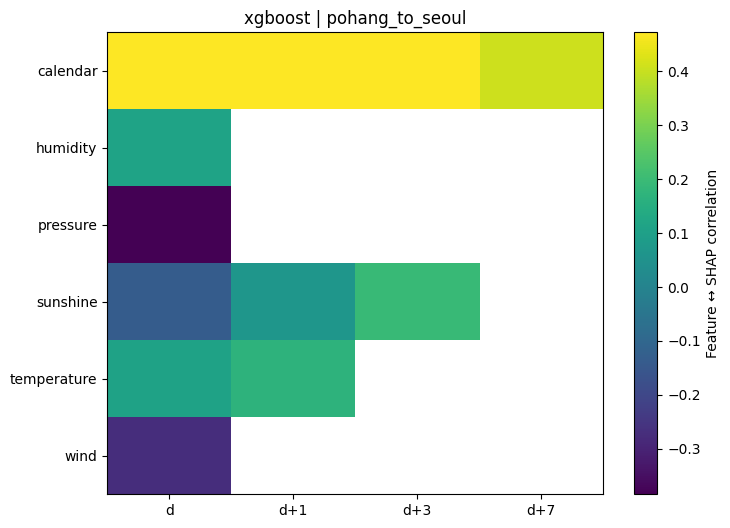

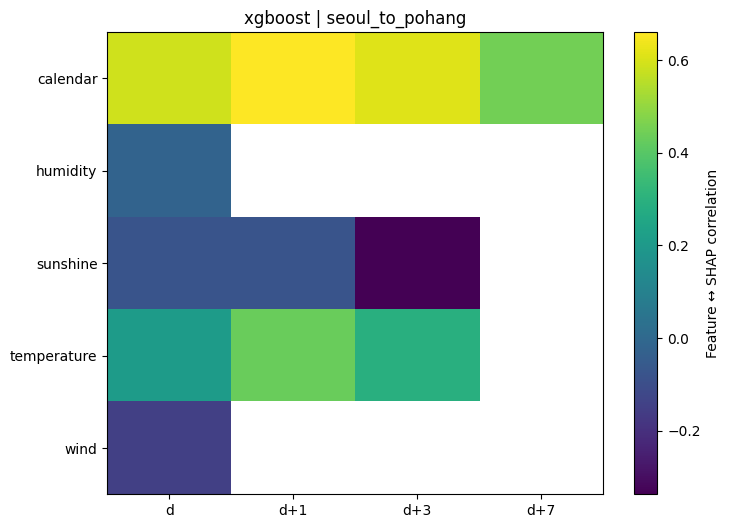

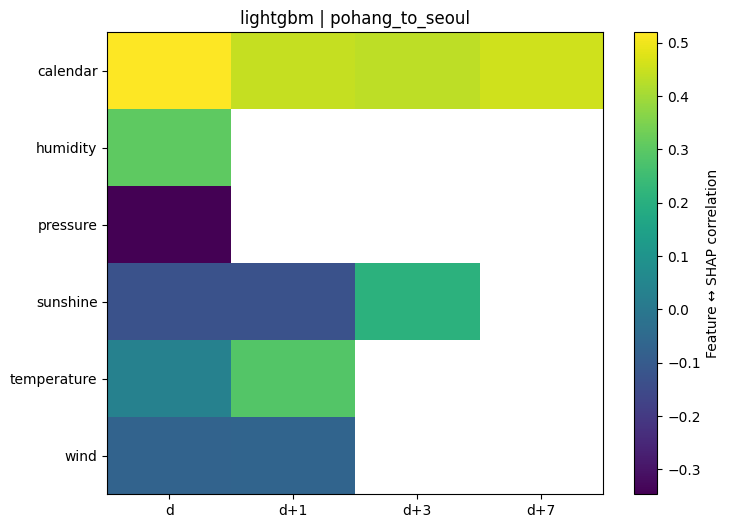

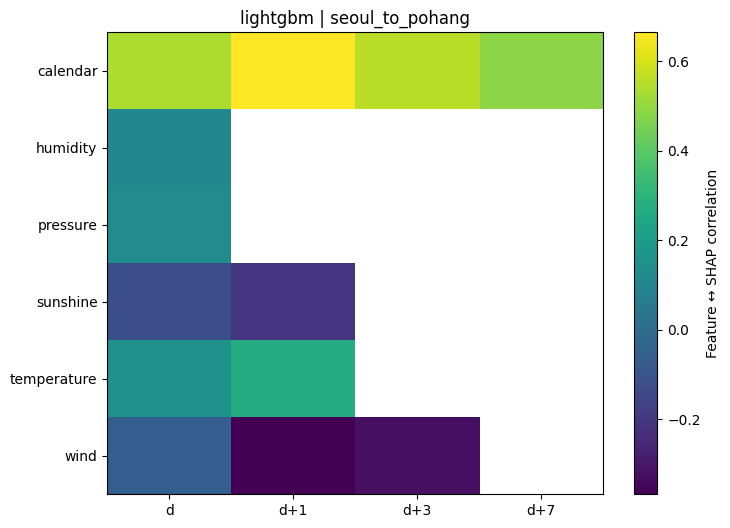

In [22]:
family_direction = (
    all_shap
    .groupby(
        [
            "model",
            "route",
            "horizon",
            "family"
        ],
        as_index=False
    )
    .apply(
        lambda x: pd.Series(
            {
                "weighted_corr": np.average(
                    x["feature_shap_corr"],
                    weights=x["importance"]
                )
            }
        )
    )
    .reset_index(drop=True)
)

for model in ["xgboost", "lightgbm"]:

    for route in sorted(all_shap["route"].unique()):

        pivot = (
            family_direction[
                (family_direction["model"] == model)
                &
                (family_direction["route"] == route)
            ]
            .pivot(
                index="family",
                columns="horizon",
                values="weighted_corr"
            )
        )

        plt.figure(figsize=(8,6))

        plt.imshow(
            pivot,
            aspect="auto"
        )

        plt.colorbar(
            label="Feature ↔ SHAP correlation"
        )

        plt.xticks(
            range(len(pivot.columns)),
            pivot.columns
        )

        plt.yticks(
            range(len(pivot.index)),
            pivot.index
        )

        plt.title(
            f"{model} | {route}"
        )

        plt.show()

## 11) Feature Importance vs Prediction Direction

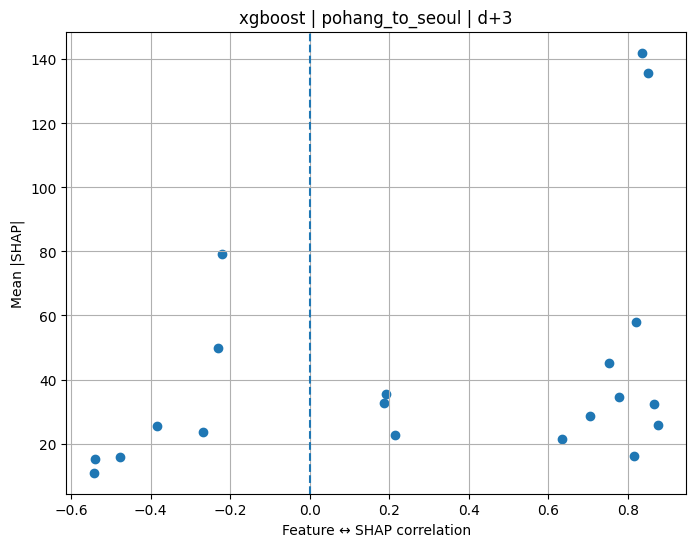

In [25]:
def plot_importance_vs_direction(case_id):

    sub = (
        all_shap[
            all_shap["case_id"] == case_id
        ]
        .copy()
    )

    plt.figure(figsize=(8,6))

    plt.scatter(
        sub["feature_shap_corr"],
        sub["importance"]
    )

    plt.axvline(
        0,
        linestyle="--"
    )

    plt.xlabel(
        "Feature ↔ SHAP correlation"
    )

    plt.ylabel(
        "Mean |SHAP|"
    )

    plt.title(
        case_id
    )

    plt.grid(True)

    plt.show()

plot_importance_vs_direction('xgboost | pohang_to_seoul | d+3')